# 06 Dinomaly final 3cat strategy V8 best epoch 15 epochs checkpoints

Objectif :

Lancer Dinomaly avec le preprocessing final sur nos 3 catégories habituelles.

Catégories traitées :

```text
hss iad | Casting_class1
hss iad | STEEL
mvtec   | cable
```

Stratégie finale utilisée :

```text
Casting_class1 : casting_class1_final_v6_base
STEEL          : steel_final_v6_erode1
cable          : cable_final_v6_erode2
```

Métriques prioritaires :

```text
image AUROC
pixel AUROC
AUPIMO
F1 image
F1 pixel
métriques par defect type
comparaison avec PatchCore V7, Dinomaly V11, Dinomaly V14 et Dinomaly V13 cable
best final 3cat par catégorie
```

Résultats :

```text
results/preprocessing_final_dinomaly_3cat_strategy/
```


Cette version ajoute une sauvegarde des checkpoints à chaque epoch puis une sélection du meilleur checkpoint disponible après inference.

## Correction V8 : selected_epoch et réutilisation des checkpoints V7

La V7 est exploitable : les entraînements passent, les checkpoints sont évalués, les métriques et les maps sont générées.

Corrections V8 :

```text
selected_epoch n est plus unknown
le parsing de epoch=004-step=6000.ckpt est corrigé
le texte Running Dinomaly final V2 est remplacé par V8
le notebook réutilise les checkpoints V7 existants si aucun checkpoint V8 n existe
les sorties finales sont sauvegardées dans un dossier V8 propre
```

Donc si la V7 a déjà généré les checkpoints, cette V8 doit normalement éviter de refaire l entraînement et seulement réévaluer les checkpoints.

## 1. Imports

In [8]:
##############
#  Imports   #
##############

import os

os.environ["PL_DISABLE_FORK"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import re
import random
import inspect
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

import torch

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("medium")

# Compatibility patch for PyTorch 2.6 checkpoint loading.
# The checkpoints are generated locally by this notebook.
# PyTorch 2.6 may default torch.load to weights_only=True, which can block Lightning checkpoints.
if not hasattr(torch, "_original_load_before_weights_only_patch"):
    torch._original_load_before_weights_only_patch = torch.load

    def torch_load_with_weights_only_false(*args, **kwargs):
        if "weights_only" not in kwargs:
            kwargs["weights_only"] = False
        return torch._original_load_before_weights_only_patch(*args, **kwargs)

    torch.load = torch_load_with_weights_only_false

print("torch.load compatibility patch active: default weights_only=False")


torch.load compatibility patch active: default weights_only=False


## 2. Configuration

In [9]:
##########################
#  Global configuration  #
##########################

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results"

PREPROCESSING_TAG = "preprocessing_final_category_strategy"
PREPROCESSING_RESULTS_DIR = RESULTS_DIR / PREPROCESSING_TAG
PREPROCESSING_DATA_DIR = PROCESSED_DIR / PREPROCESSING_TAG

FINAL_CROP_METADATA_CSV = PREPROCESSING_RESULTS_DIR / "final_category_strategy_usable_crop_metadata.csv"
FINAL_SUMMARY_CSV = PREPROCESSING_RESULTS_DIR / "final_category_strategy_summary.csv"
FINAL_RULES_CSV = PREPROCESSING_RESULTS_DIR / "final_category_strategy_model_rules.csv"
FINAL_STRATEGY_CSV = PREPROCESSING_RESULTS_DIR / "final_category_strategy.csv"

MODEL_NAME = "Dinomaly Final 3cat Strategy V8 Best Epoch 15 epochs checkpoints"
MODEL_SLUG = "dinomaly_final_3cat_strategy_v8_best_epoch_15epochs_checkpoints"

RUN_TAG = "preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints"
PREVIOUS_RUN_TAG = RUN_TAG.replace("_v8_best_epoch_15epochs_checkpoints", "_v7_best_epoch_15epochs_checkpoints")
PREVIOUS_RUN_RESULTS_DIR = RESULTS_DIR / PREVIOUS_RUN_TAG

RUN_RESULTS_DIR = RESULTS_DIR / RUN_TAG
RUN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_FOLDER_DIR = RUN_RESULTS_DIR / f"{MODEL_SLUG}_folder"
RUN_FOLDER_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PAIRS = [
    ("hss-iad", "Casting_class1"),
    ("hss-iad", "STEEL"),
    ("mvtec", "cable"),
]

IMAGE_SIZE = (448, 448)

MAX_EPOCHS = 15
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
NUM_WORKERS = 0

RUN_FULL_TEST = False

DEFAULT_MAX_TRAIN_NORMAL_CROPS = 1200
DEFAULT_MAX_TEST_NORMAL_CROPS = 250
DEFAULT_MAX_TEST_ABNORMAL_CROPS = 400

CASTING_MAX_TRAIN_NORMAL_CROPS = 1200
CASTING_MAX_TEST_NORMAL_CROPS = 120
CASTING_MAX_TEST_ABNORMAL_CROPS = 180

USE_ROI_FOR_PIXEL_METRICS = True
MASK_THRESHOLD = 127

AUPIMO_FPR_BOUNDS = (1e-5, 1e-2)
AUPIMO_NUM_THRESHOLDS = 120

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
DEVICES = 1 if torch.cuda.is_available() else "auto"

print("Model:", MODEL_NAME)
print("Run tag:", RUN_TAG)
print("Previous run tag for checkpoint reuse:", PREVIOUS_RUN_TAG)
print("torch.cuda.is_available():", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Device:", DEVICE)
print("Accelerator:", ACCELERATOR)
print("Project root:", PROJECT_ROOT)
print("Preprocessing results dir:", PREPROCESSING_RESULTS_DIR)
print("Run results dir:", RUN_RESULTS_DIR)
print("Image size:", IMAGE_SIZE)
print("Max epochs:", MAX_EPOCHS)
print("Train batch size:", TRAIN_BATCH_SIZE)
print("Eval batch size:", EVAL_BATCH_SIZE)
print("Target pairs:", TARGET_PAIRS)


# V8 best epoch settings
SAVE_ALL_EPOCH_CHECKPOINTS = True
BEST_EPOCH_SELECTION_ORDER = ["aupimo", "pixel_auroc", "image_auroc"]


Model: Dinomaly Final 3cat Strategy V8 Best Epoch 15 epochs checkpoints
Run tag: preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints
Previous run tag for checkpoint reuse: preprocessing_final_dinomaly_3cat_strategy_v7_best_epoch_15epochs_checkpoints
torch.cuda.is_available(): True
GPU: NVIDIA GeForce RTX 2070
Device: cuda
Accelerator: gpu
Project root: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus
Preprocessing results dir: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_category_strategy
Run results dir: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints
Image size: (448, 448)
Max epochs: 15
Train batch size: 1
Eval batch size: 1
Target pairs: [('hss-iad', 'Casting_class1'), ('hss-iad', 'STEEL'), ('mvtec', 'cable')]


## 3. Chargement preprocessing V7

In [10]:
##############################
#  Load final preprocessing  #
##############################

required_files = [
    FINAL_CROP_METADATA_CSV,
    FINAL_SUMMARY_CSV,
    FINAL_RULES_CSV,
    FINAL_STRATEGY_CSV,
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing final preprocessing file: {path}")

final_crop_metadata_df = pd.read_csv(FINAL_CROP_METADATA_CSV)
final_summary_df = pd.read_csv(FINAL_SUMMARY_CSV)
model_rules_df = pd.read_csv(FINAL_RULES_CSV)
strategy_df = pd.read_csv(FINAL_STRATEGY_CSV)

target_set = set(TARGET_PAIRS)

rules_keep = []

for _, row in model_rules_df.iterrows():
    pair = (row["dataset"], row["category"])
    rules_keep.append(pair in target_set)

rules_3cat_df = model_rules_df[rules_keep].copy().reset_index(drop=True)

TARGET_RUNS = []

for _, row in rules_3cat_df.iterrows():
    TARGET_RUNS.append({
        "dataset": row["dataset"],
        "category": row["category"],
        "variant_id": row["final_strategy_id"],
        "run_id": row["final_strategy_id"],
        "selected_variant_id": row["selected_variant_id"],
        "reference_image_auroc": row["reference_image_auroc"],
        "reference_pixel_auroc": row["reference_pixel_auroc"],
        "reference_aupimo": row["reference_aupimo"],
        "reference_source": row["reference_source"],
    })

keep_rows = []

for _, row in final_crop_metadata_df.iterrows():
    pair = (row["dataset"], row["category"])
    keep_rows.append(pair in target_set)

crop_df = final_crop_metadata_df[keep_rows].copy().reset_index(drop=True)

# Harmonisation avec les fonctions héritées.
crop_df["variant_id"] = crop_df["final_strategy_id"]
crop_df["run_id"] = crop_df["final_strategy_id"]
crop_df["split"] = crop_df["final_split_dir"]
crop_df["crop_image_path"] = crop_df["final_crop_image_path"]
crop_df["crop_defect_mask_path"] = crop_df["final_crop_defect_mask_path"]
crop_df["crop_roi_path"] = crop_df["final_crop_roi_path"]

print("Final crop metadata:", final_crop_metadata_df.shape)
print("3cat selected crops:", crop_df.shape)
print("3cat model rules:", rules_3cat_df.shape)

print()
print("Target runs:")
display(pd.DataFrame(TARGET_RUNS))

print()
print("3cat crop counts:")
display(
    crop_df
    .groupby(["dataset", "category", "variant_id", "split", "image_true_label", "crop_true_label"])
    .size()
    .reset_index(name="count")
)

display(crop_df.head())


Final crop metadata: (5071, 66)
3cat selected crops: (5071, 67)
3cat model rules: (3, 17)

Target runs:


,dataset,category,variant_id,run_id,selected_variant_id,reference_image_auroc,reference_pixel_auroc,reference_aupimo,reference_source
0,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,v6_base_filtered,0.750000,0.877151,0.015869,Dinomaly V14 base filtered
1,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,v6_roi_erode1_filtered,0.793440,0.771013,0.136502,Dinomaly V14 ROI erode1
2,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,v6_roi_erode2_filtered,0.981432,0.917258,0.528758,Dinomaly V14 ROI erode2



3cat crop counts:


,dataset,category,variant_id,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,casting_class1_final_v6_base,test,0,0,66
1,hss-iad,Casting_class1,casting_class1_final_v6_base,test,1,1,105
2,hss-iad,Casting_class1,casting_class1_final_v6_base,train,0,0,1200
3,hss-iad,STEEL,steel_final_v6_erode1,test,0,0,250
4,hss-iad,STEEL,steel_final_v6_erode1,test,1,1,400
5,hss-iad,STEEL,steel_final_v6_erode1,train,0,0,1200
6,mvtec,cable,cable_final_v6_erode2,test,0,0,250
7,mvtec,cable,cable_final_v6_erode2,test,1,1,400
8,mvtec,cable,cable_final_v6_erode2,train,0,0,1200


,image_id,crop_id,dataset,category,split,defect_type,image_true_label,crop_true_label,source_image_path,source_mask_path,...,test_normal_eligible,test_abnormal_eligible,final_usable,final_crop_image_path,final_crop_defect_mask_path,final_crop_roi_path,final_split_dir,final_class_dir,final_filename,run_id
0,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop00,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,True,False,True,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,test,normal,hss-iad_Casting_class1_000000_hss-iad_Casting_...,casting_class1_final_v6_base
1,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop01,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,True,False,True,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,test,normal,hss-iad_Casting_class1_000000_hss-iad_Casting_...,casting_class1_final_v6_base
2,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop02,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,True,False,True,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,test,normal,hss-iad_Casting_class1_000000_hss-iad_Casting_...,casting_class1_final_v6_base
3,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop03,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,True,False,True,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,test,normal,hss-iad_Casting_class1_000000_hss-iad_Casting_...,casting_class1_final_v6_base
4,hss-iad_Casting_class1_000000,hss-iad_Casting_class1_000000_crop04,hss-iad,Casting_class1,test,good,0,0,data/raw/hss-iad/Casting_class1/test/good/2022...,NaN,...,True,False,True,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,data/processed/preprocessing_final_category_st...,test,normal,hss-iad_Casting_class1_000000_hss-iad_Casting_...,casting_class1_final_v6_base


## 4. Sélection stricte des crops et limites

In [11]:
###########################################
#  Select usable crops and apply limits   #
###########################################

def limits_for_category(category):
    if category == "Casting_class1":
        return {
            "train": CASTING_MAX_TRAIN_NORMAL_CROPS,
            "test_normal": CASTING_MAX_TEST_NORMAL_CROPS,
            "test_abnormal": CASTING_MAX_TEST_ABNORMAL_CROPS,
        }

    return {
        "train": DEFAULT_MAX_TRAIN_NORMAL_CROPS,
        "test_normal": DEFAULT_MAX_TEST_NORMAL_CROPS,
        "test_abnormal": DEFAULT_MAX_TEST_ABNORMAL_CROPS,
    }


def limit_crop_group(group):
    if RUN_FULL_TEST:
        return group

    category = group["category"].iloc[0]
    split = str(group["split"].iloc[0]).lower()
    image_label = int(group["image_true_label"].iloc[0])
    limits = limits_for_category(category)

    if split == "train":
        limit = limits["train"]
    elif image_label == 0:
        limit = limits["test_normal"]
    else:
        limit = limits["test_abnormal"]

    if len(group) <= limit:
        return group

    sort_cols = []
    ascending = []

    for col in ["quality_score_v6", "defect_pixels_v6", "component_area"]:
        if col in group.columns:
            sort_cols.append(col)
            ascending.append(False)

    if len(sort_cols) == 0:
        return group.sample(n=limit, random_state=SEED)

    return group.sort_values(sort_cols, ascending=ascending).head(limit)


usable_flags = []

for _, row in crop_df.iterrows():
    split = str(row["split"]).lower()
    image_label = int(row["image_true_label"])
    crop_label = int(row["crop_true_label"])

    keep_row = False

    if split == "train" and image_label == 0 and crop_label == 0:
        keep_row = True

    if split == "test" and image_label == 0 and crop_label == 0:
        keep_row = True

    if split == "test" and image_label == 1 and crop_label == 1:
        keep_row = True

    usable_flags.append(keep_row)

usable_crop_df = crop_df[usable_flags].copy().reset_index(drop=True)

limited_crop_df = (
    usable_crop_df
    .groupby(["dataset", "category", "variant_id", "split", "image_true_label", "crop_true_label"], group_keys=False)
    .apply(limit_crop_group)
    .reset_index(drop=True)
)

print("Usable crops before limits:", usable_crop_df.shape)
print("Usable crops after limits:", limited_crop_df.shape)

display(
    limited_crop_df
    .groupby(["dataset", "category", "variant_id", "split", "image_true_label", "crop_true_label"])
    .size()
    .reset_index(name="count")
)


Usable crops before limits: (5071, 67)
Usable crops after limits: (5071, 67)


,dataset,category,variant_id,split,image_true_label,crop_true_label,count
0,hss-iad,Casting_class1,casting_class1_final_v6_base,test,0,0,66
1,hss-iad,Casting_class1,casting_class1_final_v6_base,test,1,1,105
2,hss-iad,Casting_class1,casting_class1_final_v6_base,train,0,0,1200
3,hss-iad,STEEL,steel_final_v6_erode1,test,0,0,250
4,hss-iad,STEEL,steel_final_v6_erode1,test,1,1,400
5,hss-iad,STEEL,steel_final_v6_erode1,train,0,0,1200
6,mvtec,cable,cable_final_v6_erode2,test,0,0,250
7,mvtec,cable,cable_final_v6_erode2,test,1,1,400
8,mvtec,cable,cable_final_v6_erode2,train,0,0,1200


## 5. Anomalib setup

In [12]:
###########################
#  Anomalib availability  #
###########################

try:
    from anomalib.data import Folder
    from anomalib.engine import Engine
    from anomalib.models import Dinomaly
    ANOMALIB_AVAILABLE = True
except Exception as error:
    ANOMALIB_AVAILABLE = False
    ANOMALIB_IMPORT_ERROR = error

print("Anomalib available:", ANOMALIB_AVAILABLE)

if not ANOMALIB_AVAILABLE:
    raise ImportError(
        "Anomalib is required for this notebook. "
        f"Original error: {ANOMALIB_IMPORT_ERROR}"
    )


Anomalib available: True


In [13]:
#####################################
#  Build Anomalib model and engine  #
#####################################

def build_dinomaly_model(image_size):
    model_signature = inspect.signature(Dinomaly)
    kwargs = {}

    if "pre_processor" in model_signature.parameters:
        kwargs["pre_processor"] = True

    model = Dinomaly(**kwargs)

    if hasattr(model, "configure_pre_processor"):
        try:
            model.pre_processor = model.configure_pre_processor(
                image_size=image_size,
            )
        except Exception as error:
            print("Could not configure pre_processor explicitly:", error)

    return model


def build_epoch_checkpoint_callback(run_root_dir):
    # Correction V4 :
    # On n utilise plus ModelCheckpoint ici.
    # Anomalib ou Lightning ajoute déjà parfois son propre ModelCheckpoint.
    # Ajouter un deuxième ModelCheckpoint provoquait :
    # "Found more than one stateful callback of type ModelCheckpoint".
    #
    # Ce callback simple sauvegarde explicitement un checkpoint à chaque epoch
    # sans entrer en conflit avec les callbacks internes de Lightning/Anomalib.
    try:
        from lightning.pytorch.callbacks import Callback
    except Exception:
        try:
            from pytorch_lightning.callbacks import Callback
        except Exception as error:
            print("Callback unavailable:", error)
            return None

    ckpt_dir = Path(run_root_dir) / "checkpoints_all_epochs"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    class SaveEveryEpochCheckpoint(Callback):
        @property
        def state_key(self):
            return "SaveEveryEpochCheckpoint_v8"

        def on_train_epoch_end(self, trainer, pl_module):
            epoch = int(getattr(trainer, "current_epoch", -1))
            step = int(getattr(trainer, "global_step", -1))
            ckpt_path = ckpt_dir / f"epoch={epoch:03d}-step={step}.ckpt"
            trainer.save_checkpoint(str(ckpt_path))
            print("Saved epoch checkpoint:", ckpt_path)

        def on_train_end(self, trainer, pl_module):
            last_path = ckpt_dir / "last.ckpt"
            trainer.save_checkpoint(str(last_path))
            print("Saved last checkpoint:", last_path)

    return SaveEveryEpochCheckpoint()


def build_csv_logger(run_root_dir):
    try:
        from lightning.pytorch.loggers import CSVLogger
    except Exception:
        try:
            from pytorch_lightning.loggers import CSVLogger
        except Exception as error:
            print("CSVLogger unavailable:", error)
            return False

    return CSVLogger(
        save_dir=str(run_root_dir),
        name="csv_logs",
    )


def build_engine(run_root_dir=None, max_epochs=None):
    if run_root_dir is None:
        run_root_dir = RUN_RESULTS_DIR / "lightning_checkpoints"

    run_root_dir = Path(run_root_dir)
    run_root_dir.mkdir(parents=True, exist_ok=True)

    engine_signature = inspect.signature(Engine)
    accepts_kwargs = any(
        param.kind == inspect.Parameter.VAR_KEYWORD
        for param in engine_signature.parameters.values()
    )

    callbacks = []
    checkpoint_callback = build_epoch_checkpoint_callback(run_root_dir)

    if checkpoint_callback is not None:
        callbacks.append(checkpoint_callback)

    logger = build_csv_logger(run_root_dir)

    kwargs = {
        "max_epochs": MAX_EPOCHS if max_epochs is None else max_epochs,
        "accelerator": ACCELERATOR,
        "devices": DEVICES,
        "logger": logger,
        "enable_checkpointing": True,
        "default_root_dir": str(run_root_dir),
        "precision": "32-true",
        "gradient_clip_val": 1.0,
        "limit_train_batches": 1.0,
        "limit_val_batches": 1.0,
        "limit_test_batches": 1.0,
        "limit_predict_batches": 1.0,
        "enable_progress_bar": False,
        "enable_model_summary": False,
        "log_every_n_steps": 50,
    }

    if callbacks:
        kwargs["callbacks"] = callbacks

    if accepts_kwargs:
        print("Engine kwargs:", kwargs)
        return Engine(**kwargs)

    filtered_kwargs = {}

    for key, value in kwargs.items():
        if key in engine_signature.parameters:
            filtered_kwargs[key] = value

    print("Engine filtered kwargs:", filtered_kwargs)
    return Engine(**filtered_kwargs)

def build_folder_datamodule(root_dir, image_size):
    sig = inspect.signature(Folder)
    kwargs = {}

    candidates = {
        "name": Path(root_dir).name,
        "root": root_dir,
        "normal_dir": "train/normal",
        "abnormal_dir": "test/abnormal",
        "normal_test_dir": "test/normal",
        "mask_dir": "ground_truth/abnormal",
        "image_size": image_size,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "num_workers": NUM_WORKERS,
    }

    for key, value in candidates.items():
        if key in sig.parameters:
            kwargs[key] = value

    return Folder(**kwargs)


def cleanup_cuda():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


## Best epoch evaluation V4

Cette version sauvegarde les checkpoints à chaque epoch puis réévalue les checkpoints disponibles.

Objectif : ne pas dépendre uniquement du dernier epoch. Le notebook sélectionne le meilleur checkpoint disponible selon l ordre suivant :

```text
AUPIMO
pixel AUROC
image AUROC
```

La sélection reste faite après inference avec nos métriques projet. Cela donne une comparaison plus rigoureuse entre best epoch et last epoch.

In [21]:
########################################
#  Best epoch checkpoint evaluation    #
########################################

BEST_EPOCH_EVAL_TABLES = []
BEST_EPOCH_SELECTION_ROWS = []


def safe_run_slug(*parts):
    text = "__".join([str(p) for p in parts])

    for char in ["/", "\\", " ", "|", ":", ";", ",", "(", ")"]:
        text = text.replace(char, "_")

    return text


def list_epoch_checkpoints(run_root_dir):
    run_root_dir = Path(run_root_dir)

    if not run_root_dir.exists():
        return []

    ckpts = sorted(
        run_root_dir.rglob("*.ckpt"),
        key=lambda p: p.stat().st_mtime,
    )

    return ckpts


def infer_epoch_from_checkpoint_path(path):
    text = Path(path).name

    match = re.search(r"epoch[=\-](\d+)", text)

    if match:
        return int(match.group(1))

    if "last" in text.lower():
        return "last"

    return "unknown"


def load_dinomaly_checkpoint(ckpt_path, image_size):
    model = build_dinomaly_model(image_size)

    ckpt = torch.load(
        str(ckpt_path),
        map_location="cpu",
        weights_only=False,
    )

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    missing, unexpected = model.load_state_dict(
        state_dict,
        strict=False,
    )

    if len(missing) > 0:
        print("Missing keys while loading checkpoint:", len(missing))

    if len(unexpected) > 0:
        print("Unexpected keys while loading checkpoint:", len(unexpected))

    return model


def metric_value(row_or_dict, names, default=np.nan):
    for name in names:

        if isinstance(row_or_dict, dict):
            if name in row_or_dict:
                return row_or_dict[name]

        elif hasattr(row_or_dict, "index"):
            if name in row_or_dict.index:
                return row_or_dict[name]

    return default


def rank_best_epoch_row(row):

    aupimo = metric_value(
        row,
        ["aupimo", "AUPIMO"],
        np.nan,
    )

    pixel_auroc = metric_value(
        row,
        ["pixel_auroc", "pixel_AUROC"],
        np.nan,
    )

    image_auroc = metric_value(
        row,
        ["roc_auc", "image_auroc", "image_AUROC"],
        np.nan,
    )

    values = []

    for value in [aupimo, pixel_auroc, image_auroc]:

        if pd.isna(value):
            values.append(-1.0)
        else:
            values.append(float(value))

    return tuple(values)


def evaluate_checkpoint_3cat(
    ckpt_path,
    datamodule,
    dataset_name,
    category_name,
    variant_id,
    run_id,
    image_size,
    eval_root_dir,
):

    model = load_dinomaly_checkpoint(
        ckpt_path,
        image_size,
    )

    engine = build_engine(
        run_root_dir=eval_root_dir / safe_run_slug(
            "eval",
            Path(ckpt_path).stem,
        ),
        max_epochs=1,
    )

    test_results = engine.test(
        model=model,
        datamodule=datamodule,
    )

    run = {
        "model": model,
        "datamodule": datamodule,
        "engine": engine,
        "test_results": test_results,
        "image_size": image_size,
        "variant_id": variant_id,
        "run_id": run_id,
    }

    pred_df = recover_predictions_with_engine(
        run=run,
        dataset_name=dataset_name,
        category_name=category_name,
        variant_id=variant_id,
        run_id=run_id,
    )

    image_pred_df = compute_image_level_predictions(pred_df)

    image_pred_df, global_img_metrics_tmp, category_metrics_tmp = (
        compute_image_metrics(image_pred_df)
    )

    defect_metrics_tmp = compute_defect_metrics(
        image_pred_df
    )

    pixel_metrics_cat, aupimo_cat_df = (
        compute_pixel_metrics_for_predictions(pred_df)
    )

    row = {
        "model": MODEL_NAME,
        "dataset": dataset_name,
        "category": category_name,
        "variant_id": variant_id,
        "run_id": run_id,
        "checkpoint_path": str(ckpt_path),
        "checkpoint_name": Path(ckpt_path).name,
        "epoch": infer_epoch_from_checkpoint_path(ckpt_path),
        "status": "ok",
        "error": "",
        "crop_predictions": len(pred_df),
        "image_predictions": len(image_pred_df),
    }

    if not category_metrics_tmp.empty:

        for col in category_metrics_tmp.columns:
            row[col] = category_metrics_tmp.iloc[0][col]

    for key, value in pixel_metrics_cat.items():
        row[key] = value

    cleanup_cuda()

    return (
        row,
        pred_df,
        image_pred_df,
        category_metrics_tmp,
        defect_metrics_tmp,
        pixel_metrics_cat,
        aupimo_cat_df,
        test_results,
    )


def evaluate_and_select_best_checkpoint_3cat(
    checkpoint_root_dir,
    datamodule,
    dataset_name,
    category_name,
    variant_id,
    run_id,
    image_size,
):

    ckpts = list_epoch_checkpoints(
        checkpoint_root_dir
    )

    if len(ckpts) == 0:
        raise RuntimeError(
            f"No checkpoints found in {checkpoint_root_dir}"
        )

    rows = []

    best_output = None
    best_row = None
    best_rank = None

    for ckpt_path in ckpts:

        print("Evaluating checkpoint:", ckpt_path)

        try:

            result = evaluate_checkpoint_3cat(
                ckpt_path=ckpt_path,
                datamodule=datamodule,
                dataset_name=dataset_name,
                category_name=category_name,
                variant_id=variant_id,
                run_id=run_id,
                image_size=image_size,
                eval_root_dir=Path(checkpoint_root_dir) / "epoch_eval_runs",
            )

            row = result[0]

            row_rank = rank_best_epoch_row(row)

            rows.append(row)

            if best_rank is None or row_rank > best_rank:

                best_rank = row_rank
                best_row = row.copy()

                if best_output is not None:
                    del best_output

                best_output = result

            else:
                del result

            cleanup_cuda()

        except Exception as error:

            rows.append({
                "model": MODEL_NAME,
                "dataset": dataset_name,
                "category": category_name,
                "variant_id": variant_id,
                "run_id": run_id,
                "checkpoint_path": str(ckpt_path),
                "checkpoint_name": Path(ckpt_path).name,
                "epoch": infer_epoch_from_checkpoint_path(ckpt_path),
                "status": "failed",
                "error": str(error),
            })

            print("Checkpoint evaluation failed:", error)

            cleanup_cuda()

    eval_df = pd.DataFrame(rows)

    ok_df = eval_df[
        eval_df["status"] == "ok"
    ].copy()

    if ok_df.empty:
        raise RuntimeError(
            "No checkpoint could be evaluated successfully"
        )

    if best_output is None:
        raise RuntimeError(
            "No best checkpoint selected"
        )

    BEST_EPOCH_EVAL_TABLES.append(eval_df)

    BEST_EPOCH_SELECTION_ROWS.append(best_row)

    print()
    print("Best checkpoint selected:")
    print(best_row["checkpoint_name"])

    print()
    print("Best epoch:")
    print(best_row["epoch"])

    print()
    print("Best AUPIMO:")
    print(best_row.get("aupimo", np.nan))

    print()
    print("Best pixel AUROC:")
    print(best_row.get("pixel_auroc", np.nan))

    print()
    print("Best image AUROC:")
    print(best_row.get("roc_auc", np.nan))

    cols = [
        "dataset",
        "category",
        "checkpoint_name",
        "epoch",
        "status",
        "roc_auc",
        "pixel_auroc",
        "aupimo",
    ]

    cols = [
        col for col in cols
        if col in eval_df.columns
    ]

    print()
    print("Checkpoint evaluation summary:")

    print(
        eval_df[cols].to_string(index=False)
    )

    return (
        best_output,
        eval_df,
        pd.Series(best_row),
    )


## 6. Folder Anomalib depuis les crops V7

In [15]:
######################################
#  Folder datamodule from crop data   #
######################################

CROP_CONTEXT = {}


def resolve_project_path(path_value):
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


def safe_name_from_crop(row):
    base = str(row.get("variant_id", "variant")) + "_" + str(row.get("image_id", "img")) + "_" + str(row.get("crop_kind", "crop"))
    base = base + "_" + str(row.get("crop_x0", 0)) + "_" + str(row.get("crop_y0", 0))
    base = base.replace("/", "_").replace("\\", "_").replace(" ", "_")
    return f"{base}.png"


def copy_one_image(src_value, dst):
    src = resolve_project_path(src_value)

    if not src.exists():
        raise FileNotFoundError(f"Missing source file: {src}")

    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return dst


def register_context(dst_image_path, row, dst_mask_path=None, dst_roi_path=None):
    context = row.to_dict()
    context["folder_image_path"] = str(dst_image_path)
    context["folder_mask_path"] = str(dst_mask_path) if dst_mask_path is not None else ""
    context["folder_roi_path"] = str(dst_roi_path) if dst_roi_path is not None else ""

    CROP_CONTEXT[str(dst_image_path)] = context
    CROP_CONTEXT[str(dst_image_path.resolve())] = context
    CROP_CONTEXT[dst_image_path.name] = context


def split_variant_crops(variant_df):
    variant_df = variant_df.copy()

    train_normal_df = variant_df[
        (variant_df["split"].astype(str).str.lower() == "train")
        & (variant_df["image_true_label"].astype(int) == 0)
        & (variant_df["crop_true_label"].astype(int) == 0)
    ].copy()

    test_normal_df = variant_df[
        (variant_df["split"].astype(str).str.lower() != "train")
        & (variant_df["image_true_label"].astype(int) == 0)
        & (variant_df["crop_true_label"].astype(int) == 0)
    ].copy()

    test_abnormal_df = variant_df[
        (variant_df["split"].astype(str).str.lower() != "train")
        & (variant_df["image_true_label"].astype(int) == 1)
        & (variant_df["crop_true_label"].astype(int) == 1)
    ].copy()

    if len(train_normal_df) == 0:
        raise ValueError("No train normal crop found")

    if len(test_normal_df) == 0:
        test_normal_df = train_normal_df.sample(
            n=min(len(train_normal_df), max(1, len(train_normal_df) // 5)),
            random_state=SEED,
        ).copy()

    return train_normal_df, test_normal_df, test_abnormal_df


def normalize_variant_for_folder_datamodule(variant_df, dataset_name, category_name, variant_id, run_id):
    safe_dataset = str(dataset_name).replace("/", "_")
    safe_category = str(category_name).replace("/", "_")
    safe_variant = str(variant_id).replace("/", "_")
    safe_run = str(run_id).replace("/", "_")
    normalized_root = RUN_FOLDER_DIR / safe_dataset / safe_category / safe_variant / safe_run

    if normalized_root.exists():
        shutil.rmtree(normalized_root)

    train_normal_dir = normalized_root / "train" / "normal"
    test_normal_dir = normalized_root / "test" / "normal"
    test_abnormal_dir = normalized_root / "test" / "abnormal"
    mask_dir = normalized_root / "ground_truth" / "abnormal"
    roi_normal_dir = normalized_root / "roi" / "normal"
    roi_abnormal_dir = normalized_root / "roi" / "abnormal"

    for folder in [
        train_normal_dir,
        test_normal_dir,
        test_abnormal_dir,
        mask_dir,
        roi_normal_dir,
        roi_abnormal_dir,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    train_normal_df, test_normal_df, test_abnormal_df = split_variant_crops(variant_df)

    counts = {
        "train_normal": 0,
        "test_normal": 0,
        "test_abnormal": 0,
        "masks": 0,
        "roi": 0,
    }

    for _, row in train_normal_df.iterrows():
        name = safe_name_from_crop(row)
        dst = train_normal_dir / name
        copy_one_image(row["crop_image_path"], dst)
        roi_dst = roi_normal_dir / name
        copy_one_image(row["crop_roi_path"], roi_dst)
        register_context(dst, row, dst_roi_path=roi_dst)
        counts["train_normal"] += 1
        counts["roi"] += 1

    for _, row in test_normal_df.iterrows():
        name = safe_name_from_crop(row)
        dst = test_normal_dir / name
        copy_one_image(row["crop_image_path"], dst)
        roi_dst = roi_normal_dir / f"test_{name}"
        copy_one_image(row["crop_roi_path"], roi_dst)
        register_context(dst, row, dst_roi_path=roi_dst)
        counts["test_normal"] += 1
        counts["roi"] += 1

    for _, row in test_abnormal_df.iterrows():
        name = safe_name_from_crop(row)
        dst = test_abnormal_dir / name
        copy_one_image(row["crop_image_path"], dst)

        mask_dst = mask_dir / name
        copy_one_image(row["crop_defect_mask_path"], mask_dst)

        roi_dst = roi_abnormal_dir / name
        copy_one_image(row["crop_roi_path"], roi_dst)

        register_context(dst, row, dst_mask_path=mask_dst, dst_roi_path=roi_dst)
        counts["test_abnormal"] += 1
        counts["masks"] += 1
        counts["roi"] += 1

    print(
        "Folder ready:",
        dataset_name,
        "|",
        category_name,
        "|",
        variant_id,
        "| train normal crops:",
        counts["train_normal"],
        "| test normal crops:",
        counts["test_normal"],
        "| test abnormal crops:",
        counts["test_abnormal"],
        "| masks:",
        counts["masks"],
        "| roi:",
        counts["roi"],
    )

    return normalized_root


def build_folder_datamodule(root_dir, image_size):
    sig = inspect.signature(Folder)
    kwargs = {}

    candidates = {
        "name": root_dir.name,
        "root": root_dir,
        "normal_dir": "train/normal",
        "abnormal_dir": "test/abnormal",
        "normal_test_dir": "test/normal",
        "mask_dir": "ground_truth/abnormal",
        "image_size": image_size,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "num_workers": NUM_WORKERS,
    }

    for key, value in candidates.items():
        if key in sig.parameters:
            kwargs[key] = value

    return Folder(**kwargs)


## 7. Récupération robuste des prédictions

In [16]:
#####################################
#  Robust prediction recovery       #
#####################################

def get_field(obj, names):
    if obj is None:
        return None

    if isinstance(obj, dict):
        for name in names:
            if name in obj:
                return obj[name]

    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)

    return None


def to_numpy(value):
    if value is None:
        return None

    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()

    return value


def normalize_array(value):
    value = to_numpy(value)

    if value is None:
        return None

    arr = np.asarray(value)

    if arr.ndim == 0:
        arr = arr.reshape(1)

    return arr


def to_path_list(value):
    if value is None:
        return []

    if isinstance(value, (str, Path)):
        return [str(value)]

    if isinstance(value, np.ndarray):
        value = value.tolist()

    try:
        return [str(x) for x in list(value)]
    except Exception:
        return [str(value)]


def get_batch_size(scores, maps, labels, paths):
    if scores is not None:
        return len(np.asarray(scores).reshape(-1))

    if maps is not None:
        maps = np.asarray(maps)
        if maps.ndim >= 3:
            return maps.shape[0]

    if labels is not None:
        return len(np.asarray(labels).reshape(-1))

    if paths:
        return len(paths)

    return 0


def get_item_from_batch(value, idx, n_items):
    arr = normalize_array(value)

    if arr is None:
        return None

    if arr.ndim == 0:
        return arr

    if arr.shape[0] == n_items:
        return arr[idx]

    return arr


def score_from_map(amap):
    if amap is None:
        return np.nan

    arr = np.asarray(amap)
    arr = np.squeeze(arr)

    if arr.size == 0:
        return np.nan

    return float(np.nanmax(arr))


def find_context_from_path(path_value):
    if path_value is None:
        return {}

    path_text = str(path_value)

    if path_text in CROP_CONTEXT:
        return CROP_CONTEXT[path_text]

    path = Path(path_text)

    if path.name in CROP_CONTEXT:
        return CROP_CONTEXT[path.name]

    try:
        resolved = str(path.resolve())
        if resolved in CROP_CONTEXT:
            return CROP_CONTEXT[resolved]
    except Exception:
        pass

    return {}


def rows_from_prediction_object(pred_obj, dataset_name, category_name, variant_id, run_id):
    scores = get_field(pred_obj, ["pred_score", "pred_scores", "score", "scores"])
    maps = get_field(pred_obj, ["anomaly_map", "anomaly_maps", "pred_mask", "pred_masks"])
    labels = get_field(pred_obj, ["gt_label", "gt_labels", "label", "labels"])
    paths = get_field(pred_obj, ["image_path", "image_paths", "path", "paths"])
    masks = get_field(pred_obj, ["gt_mask", "gt_masks", "mask", "masks"])

    scores = normalize_array(scores)
    maps = normalize_array(maps)
    labels = normalize_array(labels)
    masks = normalize_array(masks)
    paths = to_path_list(paths)

    n_items = get_batch_size(scores, maps, labels, paths)
    rows = []

    for idx in range(n_items):
        path_value = paths[idx] if idx < len(paths) else ""
        context = find_context_from_path(path_value)

        amap = get_item_from_batch(maps, idx, n_items)
        gt_mask = get_item_from_batch(masks, idx, n_items)

        if scores is not None:
            score_value = float(np.asarray(scores).reshape(-1)[idx])
        else:
            score_value = score_from_map(amap)

        if labels is not None:
            label_value = int(np.asarray(labels).reshape(-1)[idx])
        else:
            label_value = int(context.get("crop_true_label", context.get("image_true_label", 0)))

        row = {
            "model": MODEL_NAME,
            "dataset": dataset_name,
            "category": category_name,
            "variant_id": variant_id,
            "run_id": run_id,
            "score": score_value,
            "crop_true_label": label_value,
            "image_path": path_value,
            "crop_image_path": context.get("crop_image_path", path_value),
            "crop_defect_mask_path": context.get("crop_defect_mask_path", context.get("folder_mask_path", "")),
            "crop_roi_path": context.get("crop_roi_path", context.get("folder_roi_path", "")),
            "image_id": context.get("image_id", str(Path(path_value).stem)),
            "crop_id": context.get("crop_id", str(Path(path_value).stem)),
            "source_image_path": context.get("source_image_path", ""),
            "source_mask_path": context.get("source_mask_path", ""),
            "context_image_path": context.get("context_image_path", ""),
            "context_roi_path": context.get("context_roi_path", ""),
            "context_defect_mask_path": context.get("context_defect_mask_path", ""),
            "defect_type": context.get("defect_type", "unknown"),
            "split": context.get("split", ""),
            "image_true_label": int(context.get("image_true_label", label_value)),
            "crop_true_label_from_metadata": int(context.get("crop_true_label", label_value)),
            "roi_coverage": context.get("roi_coverage_crop", context.get("roi_coverage", np.nan)),
            "defect_pixels_crop": context.get("defect_pixels_crop", np.nan),
            "crop_kind": context.get("crop_kind", ""),
            "anomaly_map": amap,
            "gt_mask_array": gt_mask,
        }
        rows.append(row)

    return rows


def recover_predictions_with_engine(run, dataset_name, category_name, variant_id, run_id):
    model = run["model"]
    engine = run["engine"]
    datamodule = run["datamodule"]

    rows = []

    preds = engine.predict(model=model, datamodule=datamodule)
    print("engine.predict:", dataset_name, category_name, variant_id, "batches:", len(preds))

    for pred_obj in preds:
        rows.extend(rows_from_prediction_object(pred_obj, dataset_name, category_name, variant_id, run_id))

    return pd.DataFrame(rows)


## 8. Métriques image

In [17]:
###########################
#  Image level utilities  #
###########################

def compute_image_level_predictions(crop_pred_df):
    if crop_pred_df.empty:
        return pd.DataFrame()

    rows = []
    group_cols = ["dataset", "category", "variant_id", "run_id", "image_id"]

    for keys, group in crop_pred_df.groupby(group_cols):
        dataset, category, variant_id, run_id, image_id = keys

        score = group["score"].astype(float).max()
        true_label = int(group["image_true_label"].astype(int).max())
        best_row = group.sort_values("score", ascending=False).iloc[0]

        rows.append({
            "model": MODEL_NAME,
            "dataset": dataset,
            "category": category,
            "variant_id": variant_id,
            "run_id": run_id,
            "image_id": image_id,
            "source_image_path": best_row.get("source_image_path", ""),
            "source_mask_path": best_row.get("source_mask_path", ""),
            "defect_type": best_row.get("defect_type", "unknown"),
            "score": score,
            "true_label": true_label,
            "n_crops": len(group),
            "max_crop_id": best_row.get("crop_id", ""),
        })

    return pd.DataFrame(rows)


def compute_image_metrics(pred_df):
    if pred_df.empty:
        return pred_df, pd.DataFrame(), pd.DataFrame()

    pred_df = pred_df.copy()
    pred_df["pred_label"] = 0

    rows = []
    group_cols = ["dataset", "category", "variant_id", "run_id"]

    for keys, part in pred_df.groupby(group_cols):
        dataset, category, variant_id, run_id = keys

        y_true = part["true_label"].astype(int)
        y_score = part["score"].astype(float)

        normal_scores = part.loc[y_true == 0, "score"].astype(float)

        if len(normal_scores) > 0:
            threshold = normal_scores.quantile(0.95)
        else:
            threshold = y_score.quantile(0.95)

        idx = part.index
        pred_df.loc[idx, "pred_label"] = (
            pred_df.loc[idx, "score"].astype(float) >= threshold
        ).astype(int)

        y_pred = pred_df.loc[idx, "pred_label"].astype(int)

        row = {
            "model": MODEL_NAME,
            "dataset": dataset,
            "category": category,
            "variant_id": variant_id,
            "run_id": run_id,
            "threshold": threshold,
            "images": len(part),
            "normal_images": int((y_true == 0).sum()),
            "anomaly_images": int((y_true == 1).sum()),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
            "score_normal_mean": part.loc[y_true == 0, "score"].mean(),
            "score_anomaly_mean": part.loc[y_true == 1, "score"].mean(),
        }

        if y_true.nunique() > 1:
            row["roc_auc"] = roc_auc_score(y_true, y_score)
            row["pr_auc"] = average_precision_score(y_true, y_score)
        else:
            row["roc_auc"] = np.nan
            row["pr_auc"] = np.nan

        rows.append(row)

    category_metrics = pd.DataFrame(rows)

    y_all = pred_df["true_label"].astype(int)
    s_all = pred_df["score"].astype(float)
    p_all = pred_df["pred_label"].astype(int)

    global_row = {
        "model": MODEL_NAME,
        "images": len(pred_df),
        "normal_images": int((y_all == 0).sum()),
        "anomaly_images": int((y_all == 1).sum()),
        "accuracy": accuracy_score(y_all, p_all),
        "precision": precision_score(y_all, p_all, zero_division=0),
        "recall": recall_score(y_all, p_all, zero_division=0),
        "f1_score": f1_score(y_all, p_all, zero_division=0),
    }

    if y_all.nunique() > 1:
        global_row["roc_auc"] = roc_auc_score(y_all, s_all)
        global_row["pr_auc"] = average_precision_score(y_all, s_all)
    else:
        global_row["roc_auc"] = np.nan
        global_row["pr_auc"] = np.nan

    global_metrics = pd.DataFrame([global_row])

    return pred_df, global_metrics, category_metrics


def compute_defect_metrics(pred_df):
    rows = []

    if pred_df.empty or "pred_label" not in pred_df.columns:
        return pd.DataFrame()

    group_cols = ["dataset", "category", "variant_id", "run_id", "defect_type"]

    for keys, part in pred_df.groupby(group_cols):
        dataset, category, variant_id, run_id, defect_type = keys

        y_true = part["true_label"].astype(int)
        y_pred = part["pred_label"].astype(int)
        y_score = part["score"].astype(float)

        row = {
            "model": MODEL_NAME,
            "dataset": dataset,
            "category": category,
            "variant_id": variant_id,
            "run_id": run_id,
            "defect_type": defect_type,
            "images": len(part),
            "normal": int((y_true == 0).sum()),
            "anomalies": int(y_true.sum()),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
        }

        if y_true.nunique() > 1:
            row["roc_auc"] = roc_auc_score(y_true, y_score)
            row["pr_auc"] = average_precision_score(y_true, y_score)
        else:
            row["roc_auc"] = np.nan
            row["pr_auc"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


## 9. Métriques pixel ROI aware

In [18]:
###########################
#  Pixel level utilities  #
###########################

def project_path(path_value):
    if pd.isna(path_value):
        return None

    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


def load_binary_mask(path_value, target_shape=None):
    path = project_path(path_value)

    if path is None or not path.exists():
        return None

    mask = Image.open(path).convert("L")

    if target_shape is not None:
        h, w = target_shape
        mask = mask.resize((w, h), resample=Image.Resampling.NEAREST)

    return (np.array(mask) > MASK_THRESHOLD).astype(np.uint8)


def resize_bool_array(arr, target_shape):
    arr = np.asarray(arr).astype(np.uint8)

    if arr.shape == target_shape:
        return arr.astype(bool)

    h, w = target_shape

    resized = Image.fromarray((arr > 0).astype(np.uint8) * 255).resize(
        (w, h),
        resample=Image.Resampling.NEAREST,
    )

    return (np.array(resized) > 0)


def squeeze_map(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)
    return arr.astype(np.float32)


def get_score_map(row):
    amap = row.get("anomaly_map")

    if amap is None:
        return None

    return squeeze_map(amap)


def get_defect_mask(row, target_shape):
    mask_arr = row.get("gt_mask_array")

    if mask_arr is not None:
        mask = squeeze_map(mask_arr) > 0
        return resize_bool_array(mask, target_shape)

    mask = load_binary_mask(row.get("crop_defect_mask_path", ""), target_shape=target_shape)

    if mask is None:
        return None

    return mask.astype(bool)


def get_roi_mask(row, target_shape):
    roi = load_binary_mask(row.get("crop_roi_path", ""), target_shape=target_shape)

    if roi is None:
        return np.ones(target_shape, dtype=bool)

    roi = roi.astype(bool)

    if roi.sum() == 0:
        return np.ones(target_shape, dtype=bool)

    return roi


def collect_maps_for_metrics(predictions_df, use_roi=True):
    normal_maps = []
    normal_rois = []
    anomaly_maps = []
    anomaly_masks = []
    anomaly_rois = []

    if predictions_df.empty or "anomaly_map" not in predictions_df.columns:
        return normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois

    for _, row in predictions_df.iterrows():
        score_map = get_score_map(row)

        if score_map is None:
            continue

        roi = get_roi_mask(row, score_map.shape) if use_roi else np.ones(score_map.shape, dtype=bool)
        label = int(row.get("crop_true_label_from_metadata", row.get("crop_true_label", 0)))

        if label == 0:
            normal_maps.append(score_map)
            normal_rois.append(roi)
        else:
            mask = get_defect_mask(row, score_map.shape)

            if mask is None:
                continue

            anomaly_maps.append(score_map)
            anomaly_masks.append(mask.astype(bool))
            anomaly_rois.append(roi)

    return normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois


def flatten_maps_with_roi(maps, rois):
    values = []

    for score_map, roi in zip(maps, rois):
        score_arr = np.asarray(score_map)
        roi_arr = np.asarray(roi).astype(bool)

        if roi_arr.sum() == 0:
            continue

        values.append(score_arr[roi_arr])

    if len(values) == 0:
        return np.array([])

    return np.concatenate(values)


def flatten_anomaly_maps_and_masks(maps, masks, rois):
    scores = []
    labels = []

    for score_map, mask, roi in zip(maps, masks, rois):
        score_arr = np.asarray(score_map)
        mask_arr = np.asarray(mask).astype(bool)
        roi_arr = np.asarray(roi).astype(bool)

        valid = roi_arr

        if valid.sum() == 0:
            continue

        scores.append(score_arr[valid])
        labels.append(mask_arr[valid].astype(int))

    if len(scores) == 0:
        return np.array([]), np.array([])

    return np.concatenate(scores), np.concatenate(labels)


def compute_pixel_auroc_roi(anomaly_maps, anomaly_masks, anomaly_rois):
    y_score, y_true = flatten_anomaly_maps_and_masks(
        anomaly_maps,
        anomaly_masks,
        anomaly_rois,
    )

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true.astype(int), y_score))


def compute_pixel_f1_roi(normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois):
    normal_scores = flatten_maps_with_roi(normal_maps, normal_rois)

    if len(normal_scores) == 0:
        return np.nan

    threshold = np.quantile(normal_scores, 0.95)

    f1_values = []

    for score_map, mask, roi in zip(anomaly_maps, anomaly_masks, anomaly_rois):
        score_arr = np.asarray(score_map)
        mask_arr = np.asarray(mask).astype(bool)
        roi_arr = np.asarray(roi).astype(bool)

        valid = roi_arr

        if valid.sum() == 0:
            continue

        pred = (score_arr >= threshold) & valid
        true = mask_arr & valid

        y_true = true[valid].astype(int)
        y_pred = pred[valid].astype(int)

        if y_true.sum() == 0:
            continue

        f1_values.append(f1_score(y_true, y_pred, zero_division=0))

    if len(f1_values) == 0:
        return np.nan

    return float(np.mean(f1_values))


def compute_aupimo_roi(normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois, fpr_bounds, num_thresholds):
    normal_scores = flatten_maps_with_roi(normal_maps, normal_rois)

    if len(normal_scores) == 0 or len(anomaly_maps) == 0:
        return np.nan, pd.DataFrame()

    lower_fpr, upper_fpr = fpr_bounds
    fpr_grid = np.logspace(np.log10(lower_fpr), np.log10(upper_fpr), num_thresholds)

    thresholds = []

    for fpr in fpr_grid:
        q = 1.0 - fpr
        q = min(max(q, 0.0), 1.0)
        thresholds.append(np.quantile(normal_scores, q))

    thresholds = np.array(thresholds)

    rows = []
    aupimo_values = []
    log_fpr = np.log(fpr_grid)
    norm = log_fpr[-1] - log_fpr[0]

    for idx, (score_map, mask, roi) in enumerate(zip(anomaly_maps, anomaly_masks, anomaly_rois)):
        score_arr = np.asarray(score_map)
        mask_arr = np.asarray(mask).astype(bool)
        roi_arr = np.asarray(roi).astype(bool)

        valid_mask = mask_arr & roi_arr

        if valid_mask.sum() == 0:
            continue

        recalls = []

        for thr in thresholds:
            pred = (score_arr >= thr) & roi_arr
            recall = (pred & valid_mask).sum() / valid_mask.sum()
            recalls.append(recall)

        recalls = np.array(recalls)
        area = np.trapezoid(recalls, log_fpr) / norm
        area = float(np.clip(area, 0.0, 1.0))
        aupimo_values.append(area)

        rows.append({
            "image_index": idx,
            "aupimo": area,
            "min_recall": float(recalls.min()),
            "max_recall": float(recalls.max()),
        })

    if len(aupimo_values) == 0:
        return np.nan, pd.DataFrame(rows)

    return float(np.mean(aupimo_values)), pd.DataFrame(rows)


def compute_pixel_metrics_for_predictions(pred_df):
    normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois = collect_maps_for_metrics(
        pred_df,
        use_roi=USE_ROI_FOR_PIXEL_METRICS,
    )

    pixel_auroc = compute_pixel_auroc_roi(anomaly_maps, anomaly_masks, anomaly_rois)
    pixel_f1 = compute_pixel_f1_roi(normal_maps, normal_rois, anomaly_maps, anomaly_masks, anomaly_rois)

    aupimo, aupimo_df = compute_aupimo_roi(
        normal_maps=normal_maps,
        normal_rois=normal_rois,
        anomaly_maps=anomaly_maps,
        anomaly_masks=anomaly_masks,
        anomaly_rois=anomaly_rois,
        fpr_bounds=AUPIMO_FPR_BOUNDS,
        num_thresholds=AUPIMO_NUM_THRESHOLDS,
    )

    return {
        "pixel_auroc": pixel_auroc,
        "pixel_f1": pixel_f1,
        "aupimo": aupimo,
        "normal_maps": len(normal_maps),
        "anomaly_maps_with_masks": len(anomaly_maps),
    }, aupimo_df


## 10. Run Dinomaly final 3cat

In [19]:
#################################
#  Run one V15 target           #
#################################

def run_dinomaly_target(dataset_name, category_name, variant_id, run_id, image_size):
    variant_df = limited_crop_df[
        (limited_crop_df["variant_id"] == variant_id)
    ].copy()

    normalized_root = normalize_variant_for_folder_datamodule(
        variant_df=variant_df,
        dataset_name=dataset_name,
        category_name=category_name,
        variant_id=variant_id,
        run_id=run_id,
    )

    datamodule = build_folder_datamodule(normalized_root, image_size=image_size)
    model = build_dinomaly_model(image_size=image_size)
    engine = build_engine()

    engine.fit(model=model, datamodule=datamodule)
    test_results = engine.test(model=model, datamodule=datamodule)

    run = {
        "model": model,
        "datamodule": datamodule,
        "engine": engine,
        "test_results": test_results,
        "image_size": image_size,
        "variant_id": variant_id,
        "run_id": run_id,
    }

    pred_df = recover_predictions_with_engine(
        run=run,
        dataset_name=dataset_name,
        category_name=category_name,
        variant_id=variant_id,
        run_id=run_id,
    )

    return run, pred_df


def safe_metric_row_from_test_results(test_results, dataset_name, category_name, variant_id, run_id, status, error="", image_size=None):
    row = {
        "model": MODEL_NAME,
        "dataset": dataset_name,
        "category": category_name,
        "variant_id": variant_id,
        "run_id": run_id,
        "status": status,
        "error": error,
        "image_size": str(image_size),
    }

    if isinstance(test_results, list) and len(test_results) > 0 and isinstance(test_results[0], dict):
        row.update(test_results[0])
    elif isinstance(test_results, dict):
        row.update(test_results)

    return row


In [22]:
vars_to_check = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "RUN_TAG",
    "RUN_RESULTS_DIR",
    "MODEL_NAME",
    "MODEL_SLUG",
    "TARGET_RUNS",
    "IMAGE_SIZE",
    "MAX_EPOCHS",
    "build_engine",
    "build_dinomaly_model",
    "evaluate_and_select_best_checkpoint_3cat",
]

for var_name in vars_to_check:
    if var_name in globals():
        obj = globals()[var_name]
        print(var_name, "OK", type(obj))
    else:
        print(var_name, "MISSING")

PROJECT_ROOT OK <class 'pathlib.PosixPath'>
RESULTS_DIR OK <class 'pathlib.PosixPath'>
RUN_TAG OK <class 'str'>
RUN_RESULTS_DIR OK <class 'pathlib.PosixPath'>
MODEL_NAME OK <class 'str'>
MODEL_SLUG OK <class 'str'>
TARGET_RUNS OK <class 'list'>
IMAGE_SIZE OK <class 'tuple'>
MAX_EPOCHS OK <class 'int'>
build_engine OK <class 'function'>
build_dinomaly_model OK <class 'function'>
evaluate_and_select_best_checkpoint_3cat OK <class 'function'>


In [25]:
############################
#  Run all V8 targets       #
############################

raw_metric_rows = []
crop_prediction_tables = []
image_prediction_tables = []
category_image_metric_tables = []
defect_metric_tables = []
category_pixel_rows = []
category_aupimo_tables = []
run_status_rows = []

partial_crop_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_crop_predictions_partial.csv"
partial_image_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_image_predictions_partial.csv"
partial_category_metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_category_metrics_partial.csv"
partial_pixel_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_pixel_metrics_by_variant_partial.csv"
partial_status_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_run_status_partial.csv"
partial_epoch_eval_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_epoch_checkpoint_evaluation_partial.csv"

for item in TARGET_RUNS:
    dataset_name = item["dataset"]
    category_name = item["category"]
    variant_id = item["variant_id"]
    run_id = item["run_id"]

    print()
    print("=" * 80)
    print("Running Dinomaly final V8 best epoch:", dataset_name, "|", category_name, "|", variant_id)

    cleanup_cuda()

    success = False
    last_error = ""

    try:
        print("Using image size:", IMAGE_SIZE)

        variant_df = limited_crop_df[
            (limited_crop_df["variant_id"] == variant_id)
        ].copy()

        normalized_root = normalize_variant_for_folder_datamodule(
            variant_df=variant_df,
            dataset_name=dataset_name,
            category_name=category_name,
            variant_id=variant_id,
            run_id=run_id,
        )

        datamodule = build_folder_datamodule(normalized_root, image_size=IMAGE_SIZE)
        model = build_dinomaly_model(image_size=IMAGE_SIZE)
        train_root = RUN_RESULTS_DIR / "best_epoch_runs" / safe_run_slug(dataset_name, category_name, variant_id, run_id)
        engine = build_engine(run_root_dir=train_root)

        previous_train_root = PREVIOUS_RUN_RESULTS_DIR / "best_epoch_runs" / safe_run_slug(dataset_name, category_name, variant_id, run_id)

        existing_ckpts = list_epoch_checkpoints(train_root)
        previous_ckpts = list_epoch_checkpoints(previous_train_root)

        checkpoint_root_for_eval = train_root

        if len(existing_ckpts) > 0:
            print("Existing V8 checkpoints found:", len(existing_ckpts))
            print("Skipping training and evaluating existing V8 checkpoints.")
        elif len(previous_ckpts) > 0:
            print("Existing V7 checkpoints found:", len(previous_ckpts))
            print("Skipping training and evaluating existing V7 checkpoints.")
            checkpoint_root_for_eval = previous_train_root
        else:
            engine.fit(model=model, datamodule=datamodule)
            checkpoint_root_for_eval = train_root

        (best_output, epoch_eval_df, best_row) = evaluate_and_select_best_checkpoint_3cat(
            checkpoint_root_dir=checkpoint_root_for_eval,
            datamodule=datamodule,
            dataset_name=dataset_name,
            category_name=category_name,
            variant_id=variant_id,
            run_id=run_id,
            image_size=IMAGE_SIZE,
        )

        (
            selected_row,
            pred_df,
            image_pred_df,
            category_metrics_tmp,
            defect_metrics_tmp,
            pixel_metrics_cat,
            aupimo_cat_df,
            test_results,
        ) = best_output

        success = True

        raw_metric_rows.append(
            safe_metric_row_from_test_results(
                test_results,
                dataset_name,
                category_name,
                variant_id,
                run_id,
                status="ok",
                image_size=IMAGE_SIZE,
            ) | {
                "selected_checkpoint": selected_row.get("checkpoint_path", ""),
                "selected_epoch": selected_row.get("epoch", ""),
                "selection_metric_order": "aupimo > pixel_auroc > image_auroc",
            }
        )

        pred_df["image_size"] = str(IMAGE_SIZE)
        pred_df["selected_checkpoint"] = selected_row.get("checkpoint_path", "")
        pred_df["selected_epoch"] = selected_row.get("epoch", "")
        image_pred_df["selected_checkpoint"] = selected_row.get("checkpoint_path", "")
        image_pred_df["selected_epoch"] = selected_row.get("epoch", "")

        crop_prediction_tables.append(pred_df)
        image_prediction_tables.append(image_pred_df)
        category_image_metric_tables.append(category_metrics_tmp)
        defect_metric_tables.append(defect_metrics_tmp)

        pixel_metrics_cat.update({
            "model": MODEL_NAME,
            "dataset": dataset_name,
            "category": category_name,
            "variant_id": variant_id,
            "run_id": run_id,
            "image_size": str(IMAGE_SIZE),
            "roi_aware": USE_ROI_FOR_PIXEL_METRICS,
            "aupimo_lower_fpr": AUPIMO_FPR_BOUNDS[0],
            "aupimo_upper_fpr": AUPIMO_FPR_BOUNDS[1],
            "selected_checkpoint": selected_row.get("checkpoint_path", ""),
            "selected_epoch": selected_row.get("epoch", ""),
        })
        category_pixel_rows.append(pixel_metrics_cat)

        if not aupimo_cat_df.empty:
            aupimo_cat_df = aupimo_cat_df.copy()
            aupimo_cat_df["dataset"] = dataset_name
            aupimo_cat_df["category"] = category_name
            aupimo_cat_df["variant_id"] = variant_id
            aupimo_cat_df["run_id"] = run_id
            aupimo_cat_df["image_size"] = str(IMAGE_SIZE)
            aupimo_cat_df["selected_checkpoint"] = selected_row.get("checkpoint_path", "")
            aupimo_cat_df["selected_epoch"] = selected_row.get("epoch", "")
            category_aupimo_tables.append(aupimo_cat_df)

        run_status_rows.append({
            "dataset": dataset_name,
            "category": category_name,
            "variant_id": variant_id,
            "run_id": run_id,
            "status": "ok",
            "image_size": str(IMAGE_SIZE),
            "error": "",
            "crop_predictions": len(pred_df),
            "selected_checkpoint": selected_row.get("checkpoint_path", ""),
            "selected_epoch": selected_row.get("epoch", ""),
        })

        pd.concat(crop_prediction_tables, ignore_index=True).drop(
            columns=["anomaly_map", "gt_mask_array"],
            errors="ignore",
        ).to_csv(partial_crop_path, index=False)

        pd.concat(image_prediction_tables, ignore_index=True).to_csv(partial_image_path, index=False)
        pd.concat(category_image_metric_tables, ignore_index=True).to_csv(partial_category_metrics_path, index=False)
        pd.DataFrame(category_pixel_rows).to_csv(partial_pixel_path, index=False)
        pd.DataFrame(run_status_rows).to_csv(partial_status_path, index=False)

        if BEST_EPOCH_EVAL_TABLES:
            pd.concat(BEST_EPOCH_EVAL_TABLES, ignore_index=True).to_csv(partial_epoch_eval_path, index=False)

        print("Partial outputs saved")
        print("Selected checkpoint:", selected_row.get("checkpoint_path", ""))
        print("Selected epoch:", selected_row.get("epoch", ""))
        print("Pixel metrics:", pixel_metrics_cat)

        del model, engine, datamodule
        cleanup_cuda()

    except RuntimeError as error:
        last_error = str(error)
        print("RuntimeError:", last_error)
        cleanup_cuda()

    except Exception as error:
        last_error = str(error)
        print("Failed:", dataset_name, category_name, error)
        cleanup_cuda()

    if not success:
        raw_metric_rows.append(
            safe_metric_row_from_test_results(
                {},
                dataset_name,
                category_name,
                variant_id,
                run_id,
                status="failed",
                error=last_error,
                image_size=IMAGE_SIZE,
            )
        )
        run_status_rows.append({
            "dataset": dataset_name,
            "category": category_name,
            "variant_id": variant_id,
            "run_id": run_id,
            "status": "failed",
            "image_size": str(IMAGE_SIZE),
            "error": last_error,
            "crop_predictions": 0,
            "selected_checkpoint": "",
            "selected_epoch": "",
        })
        pd.DataFrame(run_status_rows).to_csv(partial_status_path, index=False)

raw_dinomaly_metrics_df = pd.DataFrame(raw_metric_rows)
run_status_df = pd.DataFrame(run_status_rows)

best_epoch_evaluation_df = (
    pd.concat(BEST_EPOCH_EVAL_TABLES, ignore_index=True)
    if BEST_EPOCH_EVAL_TABLES
    else pd.DataFrame()
)

best_epoch_selection_df = pd.DataFrame(BEST_EPOCH_SELECTION_ROWS)

dinomaly_crop_predictions_df = (
    pd.concat(crop_prediction_tables, ignore_index=True)
    if crop_prediction_tables
    else pd.DataFrame()
)

dinomaly_image_predictions_df = (
    pd.concat(image_prediction_tables, ignore_index=True)
    if image_prediction_tables
    else pd.DataFrame()
)

category_metrics_df = (
    pd.concat(category_image_metric_tables, ignore_index=True)
    if category_image_metric_tables
    else pd.DataFrame()
)

defect_metrics_df = (
    pd.concat(defect_metric_tables, ignore_index=True)
    if defect_metric_tables
    else pd.DataFrame()
)

category_pixel_metrics_df = pd.DataFrame(category_pixel_rows)

category_aupimo_per_image_df = (
    pd.concat(category_aupimo_tables, ignore_index=True)
    if category_aupimo_tables
    else pd.DataFrame()
)

print()
print("Run status:")
display(run_status_df)

print("Best epoch selection:")
display(best_epoch_selection_df)

print("Best epoch evaluation:")
display(best_epoch_evaluation_df)

print("Raw Dinomaly metrics:")
display(raw_dinomaly_metrics_df)

print("Image metrics:")
display(category_metrics_df)

print("Pixel metrics:")
display(category_pixel_metrics_df)



Running Dinomaly final V8 best epoch: hss-iad | Casting_class1 | casting_class1_final_v6_base
Using image size: (448, 448)
Folder ready: hss-iad | Casting_class1 | casting_class1_final_v6_base | train normal crops: 1200 | test normal crops: 66 | test abnormal crops: 105 | masks: 105 | roi: 1371
Engine kwargs: {'max_epochs': 15, 'accelerator': 'gpu', 'devices': 1, 'logger': <lightning.pytorch.loggers.csv_logs.CSVLogger object at 0x7fe7c6e7f2c0>, 'enable_checkpointing': True, 'default_root_dir': '/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints/best_epoch_runs/hss-iad__Casting_class1__casting_class1_final_v6_base__casting_class1_final_v6_base', 'precision': '32-true', 'gradient_clip_val': 1.0, 'limit_train_batches': 1.0, 'limit_val_batches': 1.0, 'limit_test_batches': 1.0, 'limit_predict_batches': 1.0, 'enable_progress_bar': False, 'enable_model_summary': False, 'log_every_n_steps': 50, 'cal

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
`Trainer(limit_test_batches=1.0)` was configured so 100% of the batches will be used..
`Trainer(limit_predict_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Engine kwargs: {'max_epochs': 1, 'accelerator': 'gpu', 'devices': 1, 'logger': <lightning.pytorch.loggers.csv_logs.CSVLogger object at 0x7fe8df71ee40>, 'enable_checkpointing': True, 'default_root_dir': '/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v7_best_epoch_15epochs_checkpoints/best_epoch_runs/hss-iad__Casting_class1__casting_class1_final_v6_base__casting_class1_final_v6_base/epoch_eval_runs/eval__epoch=000-step=1200', 'precision': '32-true', 'gradient_clip_val': 1.0, 'limit_train_batches': 1.0, 'limit_val_batches': 1.0, 'limit_test_batches': 1.0, 'limit_predict_batches': 1.0, 'enable_progress_bar': False, 'enable_model_summary': False, 'log_every_n_steps': 50, 'callbacks': [<__main__.build_epoch_checkpoint_callback.<locals>.SaveEveryEpochCheckpoint object at 0x7fe7c6bcb5c0>]}


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.49857062101364136    │
│       image_F1Score       │    0.7681159377098083     │
│        pixel_AUROC        │     0.358379065990448     │
│       pixel_F1Score       │   0.010054797865450382    │
└───────────────────────────┴───────────────────────────┘

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

,model,dataset,category,variant_id,run_id,status,error,image_size,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score,selected_checkpoint,selected_epoch,selection_metric_order
0,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,ok,,"(448, 448)",0.746141,0.837607,0.882544,0.148057,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4,aupimo > pixel_auroc > image_auroc
1,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,ok,,"(448, 448)",0.478740,0.761905,0.475265,0.261077,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0,aupimo > pixel_auroc > image_auroc
2,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,ok,,"(448, 448)",0.995800,0.965686,0.943493,0.741012,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13,aupimo > pixel_auroc > image_auroc


Image metrics:


,model,dataset,category,variant_id,run_id,threshold,images,normal_images,anomaly_images,accuracy,precision,recall,f1_score,score_normal_mean,score_anomaly_mean,roc_auc,pr_auc
0,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,1.000000,30,11,19,0.600000,0.818182,0.473684,0.600000,0.716348,0.881409,0.722488,0.786237
1,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,1.000000,160,79,81,0.537500,0.543210,0.543210,0.543210,0.941885,0.956881,0.552430,0.539386
2,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,0.527385,132,54,78,0.969697,0.962500,0.987179,0.974684,0.476918,0.779856,0.998338,0.998884


Pixel metrics:


,pixel_auroc,pixel_f1,aupimo,normal_maps,anomaly_maps_with_masks,model,dataset,category,variant_id,run_id,image_size,roi_aware,aupimo_lower_fpr,aupimo_upper_fpr,selected_checkpoint,selected_epoch
0,0.884505,0.185685,0.053260,33,53,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4
1,0.472696,0.295040,0.478768,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0
2,0.920891,0.620986,0.570663,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13


In [26]:
vars_to_check = [
    "run_status_df",
    "best_epoch_selection_df",
    "best_epoch_evaluation_df",
    "raw_dinomaly_metrics_df",
    "category_metrics_df",
    "category_pixel_metrics_df",
]

for v in vars_to_check:
    if v in globals():
        obj = globals()[v]
        print(v, "OK", getattr(obj, "shape", "no shape"))
        try:
            display(obj.head())
        except Exception as e:
            print("display impossible:", e)
    else:
        print(v, "MISSING")

run_status_df OK (3, 10)


,dataset,category,variant_id,run_id,status,image_size,error,crop_predictions,selected_checkpoint,selected_epoch
0,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,ok,"(448, 448)",,86,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4
1,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,ok,"(448, 448)",,325,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0
2,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,ok,"(448, 448)",,325,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13


best_epoch_selection_df OK (3, 29)


,model,dataset,category,variant_id,run_id,checkpoint_path,checkpoint_name,epoch,status,error,...,f1_score,score_normal_mean,score_anomaly_mean,roc_auc,pr_auc,pixel_auroc,pixel_f1,aupimo,normal_maps,anomaly_maps_with_masks
0,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,epoch=004-step=6000.ckpt,4,ok,,...,0.600000,0.716348,0.881409,0.722488,0.786237,0.884505,0.185685,0.053260,33,53
1,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,epoch=000-step=1200.ckpt,0,ok,,...,0.543210,0.941885,0.956881,0.552430,0.539386,0.472696,0.295040,0.478768,125,200
2,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,epoch=013-step=16800.ckpt,13,ok,,...,0.974684,0.476918,0.779856,0.998338,0.998884,0.920891,0.620986,0.570663,125,200


best_epoch_evaluation_df OK (51, 29)


...

,model,dataset,category,variant_id,run_id,status,error,image_size,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score,selected_checkpoint,selected_epoch,selection_metric_order
0,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,ok,,"(448, 448)",0.746141,0.837607,0.882544,0.148057,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4,aupimo > pixel_auroc > image_auroc
1,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,ok,,"(448, 448)",0.478740,0.761905,0.475265,0.261077,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0,aupimo > pixel_auroc > image_auroc
2,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,ok,,"(448, 448)",0.995800,0.965686,0.943493,0.741012,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13,aupimo > pixel_auroc > image_auroc


category_metrics_df OK (3, 17)


,model,dataset,category,variant_id,run_id,threshold,images,normal_images,anomaly_images,accuracy,precision,recall,f1_score,score_normal_mean,score_anomaly_mean,roc_auc,pr_auc
0,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,1.000000,30,11,19,0.600000,0.818182,0.473684,0.600000,0.716348,0.881409,0.722488,0.786237
1,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,1.000000,160,79,81,0.537500,0.543210,0.543210,0.543210,0.941885,0.956881,0.552430,0.539386
2,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,0.527385,132,54,78,0.969697,0.962500,0.987179,0.974684,0.476918,0.779856,0.998338,0.998884


category_pixel_metrics_df OK (3, 16)


,pixel_auroc,pixel_f1,aupimo,normal_maps,anomaly_maps_with_masks,model,dataset,category,variant_id,run_id,image_size,roi_aware,aupimo_lower_fpr,aupimo_upper_fpr,selected_checkpoint,selected_epoch
0,0.884505,0.185685,0.053260,33,53,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4
1,0.472696,0.295040,0.478768,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0
2,0.920891,0.620986,0.570663,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13


## 11. Comparaison avec les résultats précédents

In [27]:
##############################################
#  Comparison with previous results          #
##############################################

comparison_rows = []

target_pairs = []

for item in TARGET_RUNS:
    target_pairs.append((item["dataset"], item["category"]))

# PatchCore V7
patchcore_cat_pixel_path = RESULTS_DIR / "preprocessing_v7_patchcore_category_strategy" / "patchcore_v7_category_strategy_pixel_metrics_by_category.csv"
patchcore_cat_image_path = RESULTS_DIR / "preprocessing_v7_patchcore_category_strategy" / "patchcore_v7_category_strategy_category_metrics.csv"

if patchcore_cat_pixel_path.exists() and patchcore_cat_image_path.exists():
    patch_pix = pd.read_csv(patchcore_cat_pixel_path)
    patch_img = pd.read_csv(patchcore_cat_image_path)

    for dataset, category in target_pairs:
        p_pix = patch_pix[(patch_pix["dataset"] == dataset) & (patch_pix["category"] == category)]
        p_img = patch_img[(patch_img["dataset"] == dataset) & (patch_img["category"] == category)]

        comparison_rows.append({
            "model": "PatchCore V7",
            "dataset": dataset,
            "category": category,
            "strategy_id": "",
            "image_auroc": p_img.iloc[0].get("roc_auc", np.nan) if len(p_img) else np.nan,
            "pixel_auroc": p_pix.iloc[0].get("pixel_auroc", np.nan) if len(p_pix) else np.nan,
            "aupimo": p_pix.iloc[0].get("aupimo", np.nan) if len(p_pix) else np.nan,
        })

# Dinomaly V11
v11_pixel_path = RESULTS_DIR / "preprocessing_v11_dinomaly_checkpoint_fix_3cat" / "dinomaly_v11_checkpoint_fix_3cat_pixel_metrics_by_category.csv"
v11_image_path = RESULTS_DIR / "preprocessing_v11_dinomaly_checkpoint_fix_3cat" / "dinomaly_v11_checkpoint_fix_3cat_category_metrics.csv"

if v11_pixel_path.exists() and v11_image_path.exists():
    v11_pix = pd.read_csv(v11_pixel_path)
    v11_img = pd.read_csv(v11_image_path)

    for dataset, category in target_pairs:
        p_pix = v11_pix[(v11_pix["dataset"] == dataset) & (v11_pix["category"] == category)]
        p_img = v11_img[(v11_img["dataset"] == dataset) & (v11_img["category"] == category)]

        comparison_rows.append({
            "model": "Dinomaly V11",
            "dataset": dataset,
            "category": category,
            "strategy_id": "",
            "image_auroc": p_img.iloc[0].get("roc_auc", np.nan) if len(p_img) else np.nan,
            "pixel_auroc": p_pix.iloc[0].get("pixel_auroc", np.nan) if len(p_pix) else np.nan,
            "aupimo": p_pix.iloc[0].get("aupimo", np.nan) if len(p_pix) else np.nan,
        })

# Dinomaly V14
v14_pixel_path = RESULTS_DIR / "preprocessing_v14_dinomaly_3cat_from_v6" / "dinomaly_v14_3cat_from_v6_pixel_metrics_by_run.csv"
v14_image_path = RESULTS_DIR / "preprocessing_v14_dinomaly_3cat_from_v6" / "dinomaly_v14_3cat_from_v6_category_metrics.csv"

if v14_pixel_path.exists() and v14_image_path.exists():
    v14_pix = pd.read_csv(v14_pixel_path)
    v14_img = pd.read_csv(v14_image_path)

    for dataset, category in target_pairs:
        v14_cat_pix = v14_pix[(v14_pix["dataset"] == dataset) & (v14_pix["category"] == category)]

        for _, p_pix in v14_cat_pix.iterrows():
            p_img = v14_img[
                (v14_img["dataset"] == dataset)
                & (v14_img["category"] == category)
                & (v14_img["variant_id"] == p_pix.get("variant_id", ""))
                & (v14_img["run_id"] == p_pix.get("run_id", ""))
            ]

            comparison_rows.append({
                "model": "Dinomaly V14",
                "dataset": dataset,
                "category": category,
                "strategy_id": p_pix.get("variant_id", ""),
                "image_auroc": p_img.iloc[0].get("roc_auc", np.nan) if len(p_img) else np.nan,
                "pixel_auroc": p_pix.get("pixel_auroc", np.nan),
                "aupimo": p_pix.get("aupimo", np.nan),
            })

# Dinomaly V13 cable best
v13_variant_path = RESULTS_DIR / "preprocessing_v13_dinomaly_cable_aupimo_boost" / "dinomaly_v13_cable_aupimo_boost_roi_map_variant_metrics.csv"
v13_image_path = RESULTS_DIR / "preprocessing_v13_dinomaly_cable_aupimo_boost" / "dinomaly_v13_cable_aupimo_boost_roi_category_metrics.csv"

if v13_variant_path.exists():
    v13_var = pd.read_csv(v13_variant_path)

    if len(v13_var):
        best = v13_var.sort_values(["aupimo", "pixel_auroc"], ascending=False).iloc[0]
        image_auroc = np.nan

        if v13_image_path.exists():
            v13_img = pd.read_csv(v13_image_path)
            if len(v13_img):
                image_auroc = v13_img.iloc[0].get("roc_auc", np.nan)

        comparison_rows.append({
            "model": "Dinomaly V13 best cable",
            "dataset": "mvtec",
            "category": "cable",
            "strategy_id": best.get("variant_name", ""),
            "image_auroc": image_auroc,
            "pixel_auroc": best.get("pixel_auroc", np.nan),
            "aupimo": best.get("aupimo", np.nan),
        })

# Final 3cat
if not category_metrics_df.empty:
    for _, row in category_metrics_df.iterrows():
        p_pix = category_pixel_metrics_df[
            (category_pixel_metrics_df["variant_id"] == row["variant_id"])
            & (category_pixel_metrics_df["run_id"] == row["run_id"])
        ]

        comparison_rows.append({
            "model": "Dinomaly Final 3cat",
            "dataset": row["dataset"],
            "category": row["category"],
            "strategy_id": row.get("variant_id", ""),
            "image_auroc": row.get("roc_auc", np.nan),
            "pixel_auroc": p_pix.iloc[0].get("pixel_auroc", np.nan) if len(p_pix) else np.nan,
            "aupimo": p_pix.iloc[0].get("aupimo", np.nan) if len(p_pix) else np.nan,
        })

comparison_df = pd.DataFrame(comparison_rows)

print("Comparison:")
display(
    comparison_df.sort_values(["dataset", "category", "model", "strategy_id"])
    if not comparison_df.empty
    else comparison_df
)

if not category_pixel_metrics_df.empty:
    best_final_df = (
        category_pixel_metrics_df
        .sort_values(["category", "aupimo", "pixel_auroc"], ascending=[True, False, False])
        .groupby(["dataset", "category"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    print("Best final 3cat by category:")
    display(best_final_df)
else:
    best_final_df = pd.DataFrame()


Comparison:


,model,dataset,category,strategy_id,image_auroc,pixel_auroc,aupimo
13,Dinomaly Final 3cat,hss-iad,Casting_class1,casting_class1_final_v6_base,0.722488,0.884505,0.053260
3,Dinomaly V11,hss-iad,Casting_class1,,0.678788,0.893187,0.024018
6,Dinomaly V14,hss-iad,Casting_class1,v6_base_filtered,0.750000,0.877151,0.015869
7,Dinomaly V14,hss-iad,Casting_class1,v6_roi_erode2_filtered,0.600877,0.751440,0.000068
0,PatchCore V7,hss-iad,Casting_class1,,0.539474,0.905143,0.052605
14,Dinomaly Final 3cat,hss-iad,STEEL,steel_final_v6_erode1,0.552430,0.472696,0.478768
4,Dinomaly V11,hss-iad,STEEL,,0.567982,0.784482,0.020334
8,Dinomaly V14,hss-iad,STEEL,v6_base_filtered,0.795892,0.801360,0.101354
9,Dinomaly V14,hss-iad,STEEL,v6_roi_erode1_filtered,0.793440,0.771013,0.136502
1,PatchCore V7,hss-iad,STEEL,,0.458951,0.810103,0.005525


Best final 3cat by category:


,pixel_auroc,pixel_f1,aupimo,normal_maps,anomaly_maps_with_masks,model,dataset,category,variant_id,run_id,image_size,roi_aware,aupimo_lower_fpr,aupimo_upper_fpr,selected_checkpoint,selected_epoch
0,0.884505,0.185685,0.053260,33,53,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,Casting_class1,casting_class1_final_v6_base,casting_class1_final_v6_base,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,4
1,0.472696,0.295040,0.478768,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,hss-iad,STEEL,steel_final_v6_erode1,steel_final_v6_erode1,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,0
2,0.920891,0.620986,0.570663,125,200,Dinomaly Final 3cat Strategy V8 Best Epoch 15 ...,mvtec,cable,cable_final_v6_erode2,cable_final_v6_erode2,"(448, 448)",True,0.00001,0.01,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,13


## 12. Visualisation des prédictions


Visual samples for: casting_class1_final_v6_base


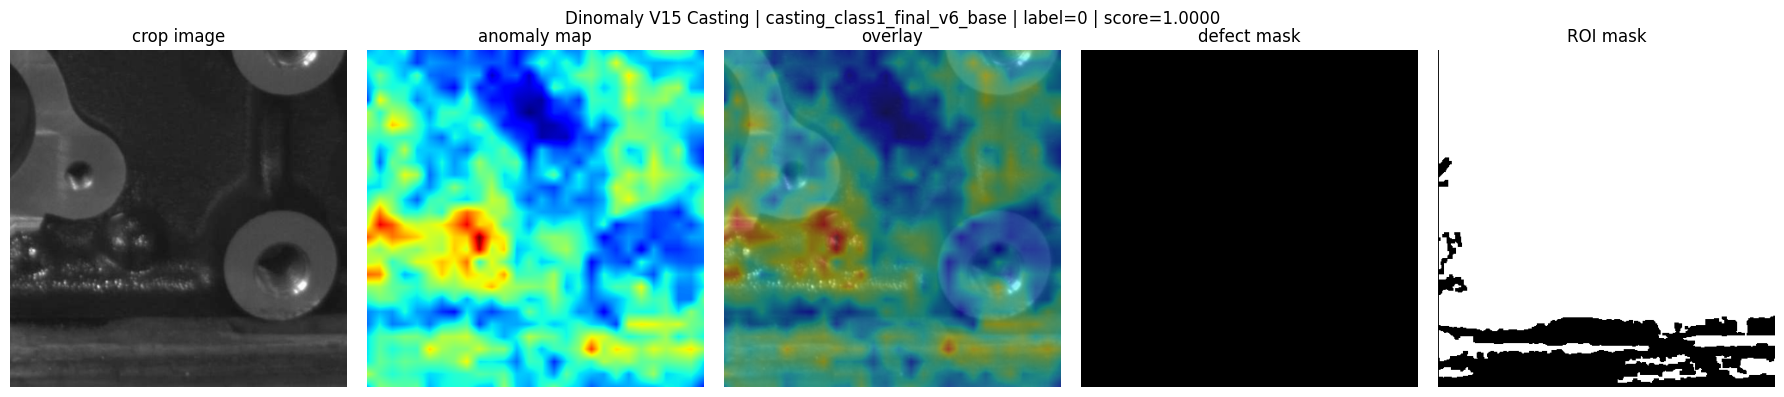

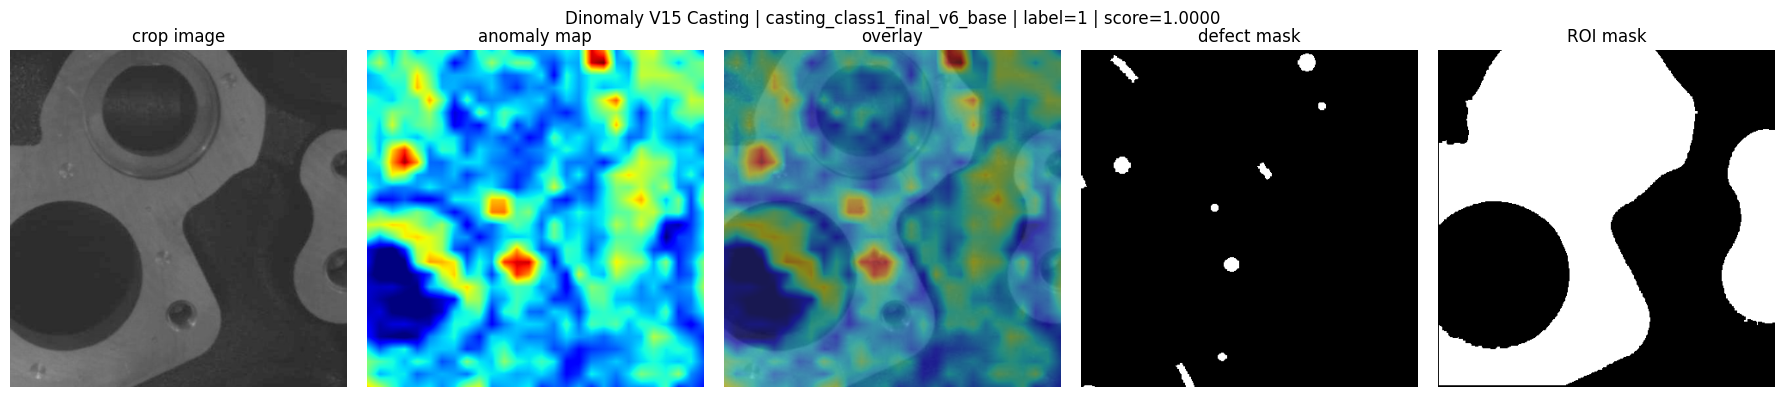

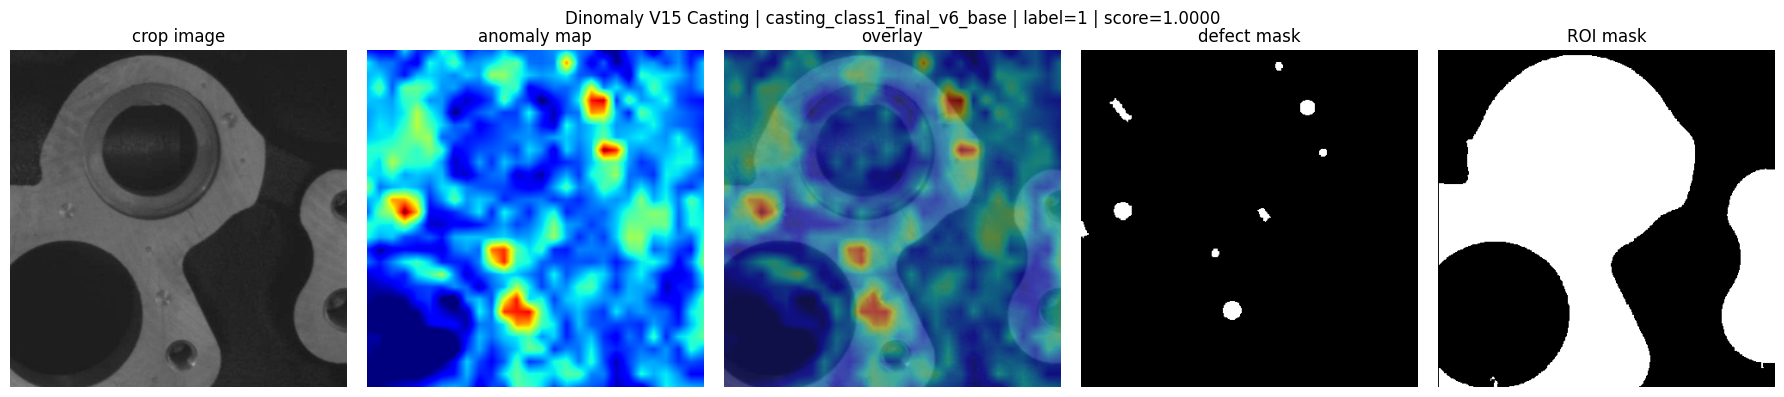

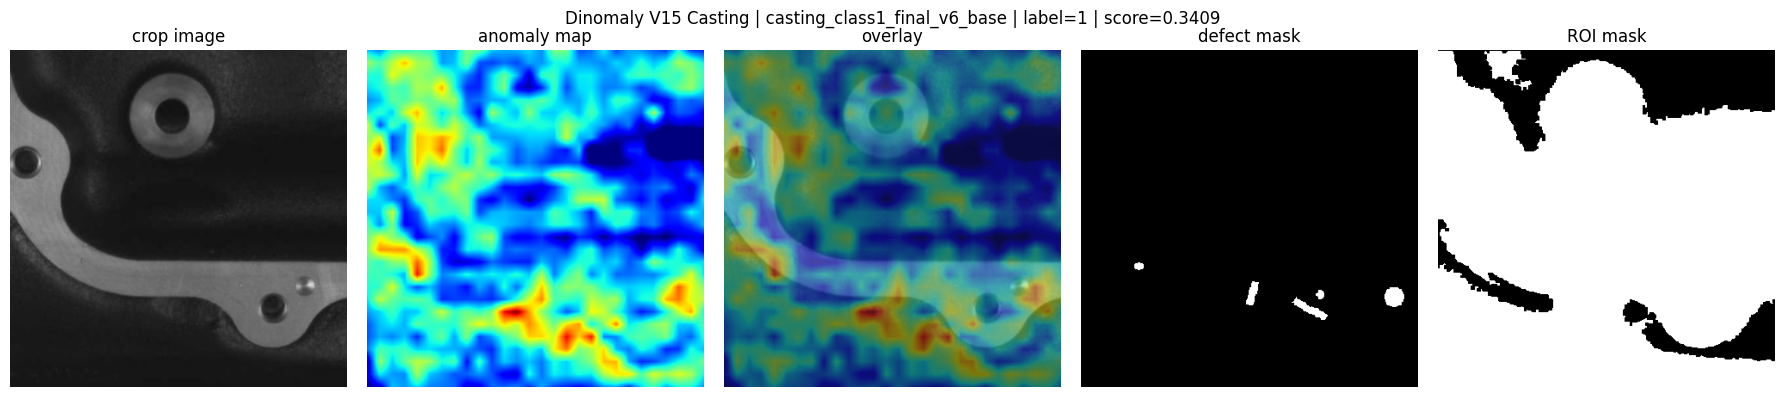


Visual samples for: steel_final_v6_erode1


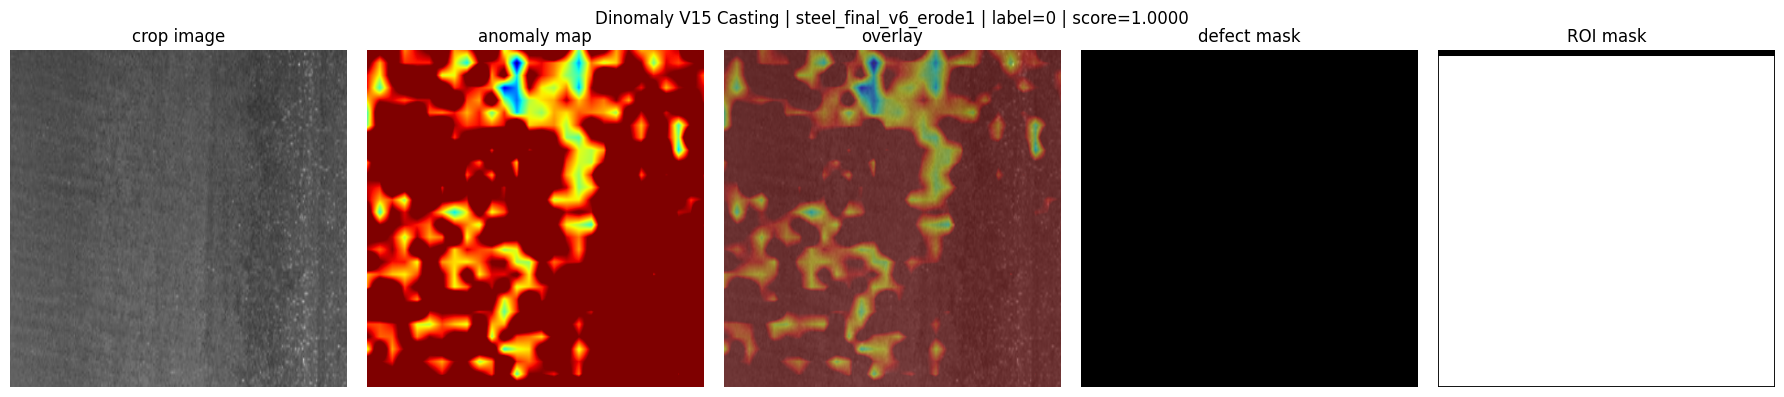

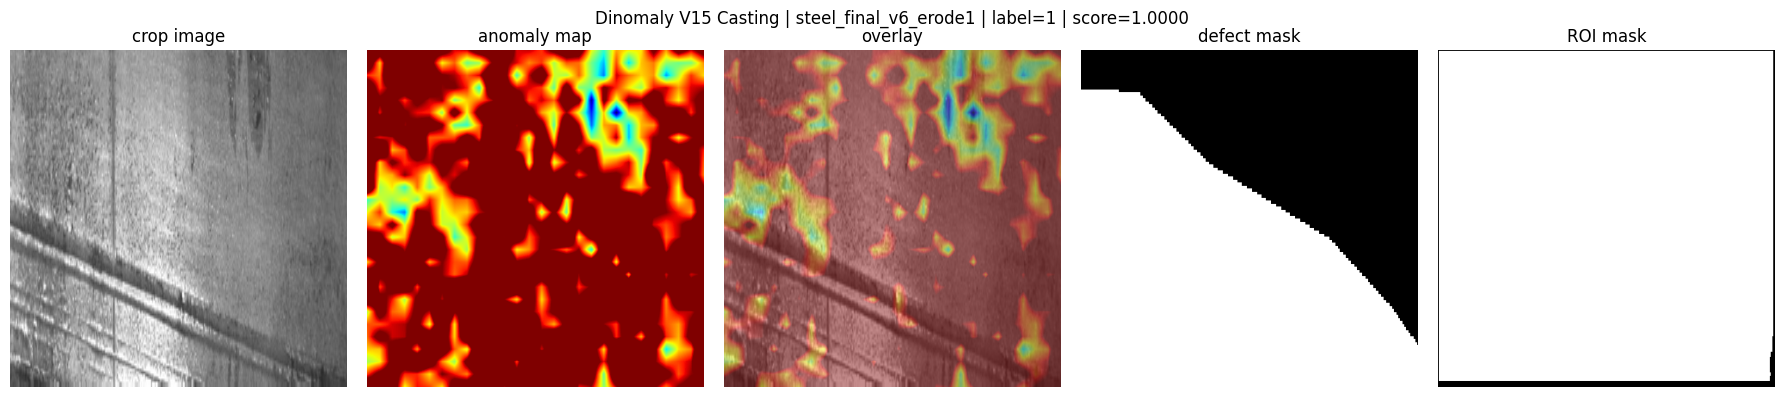

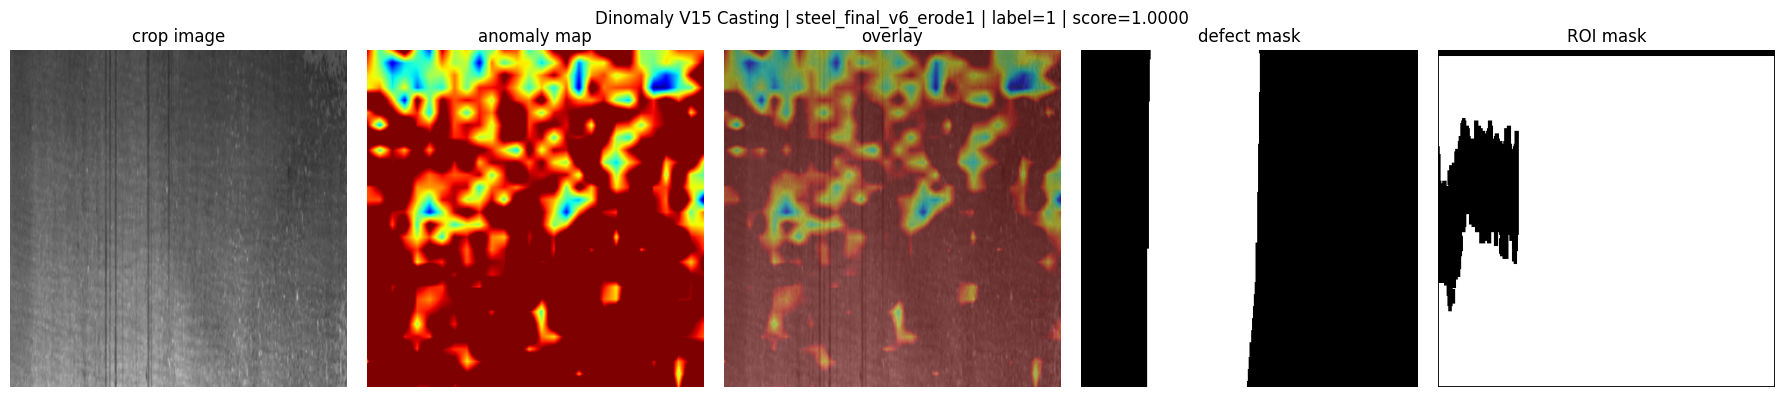

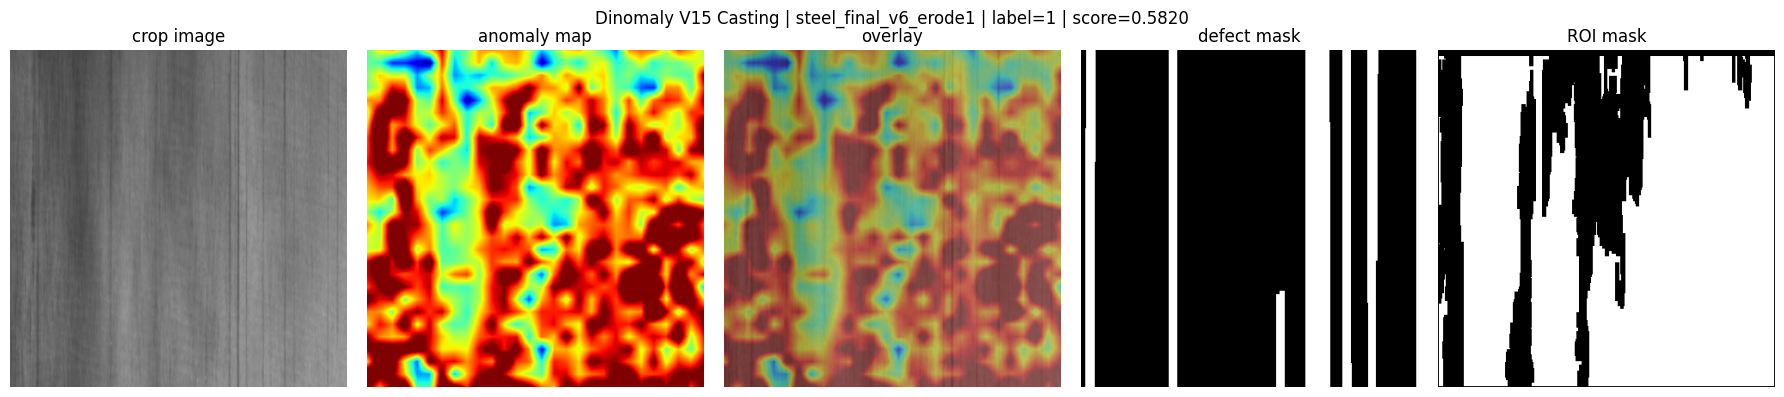


Visual samples for: cable_final_v6_erode2


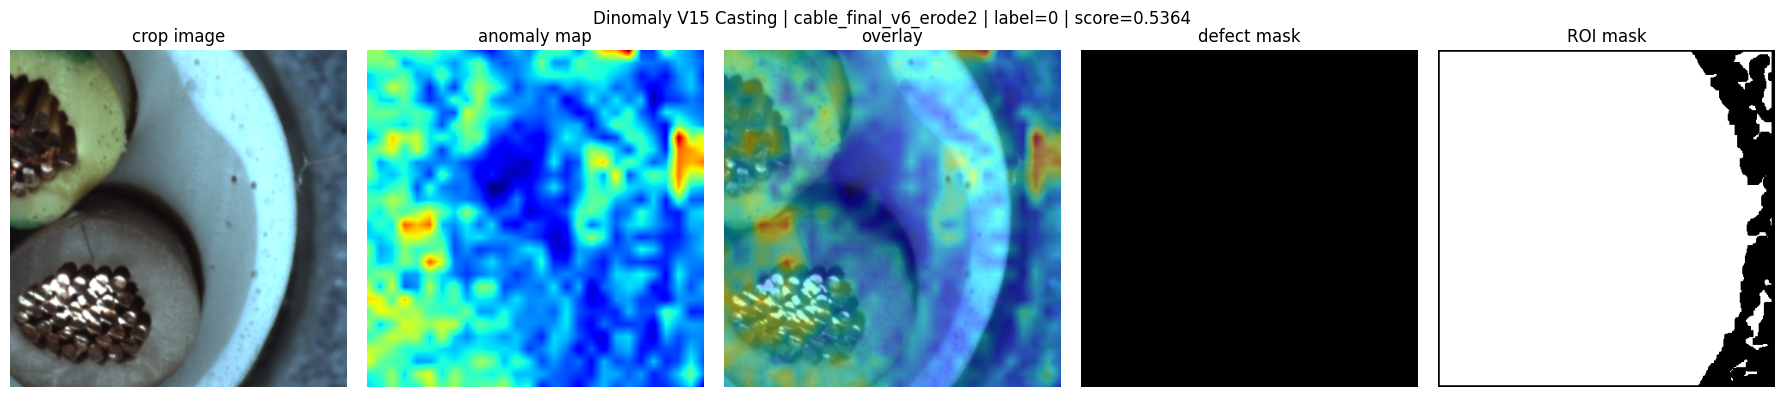

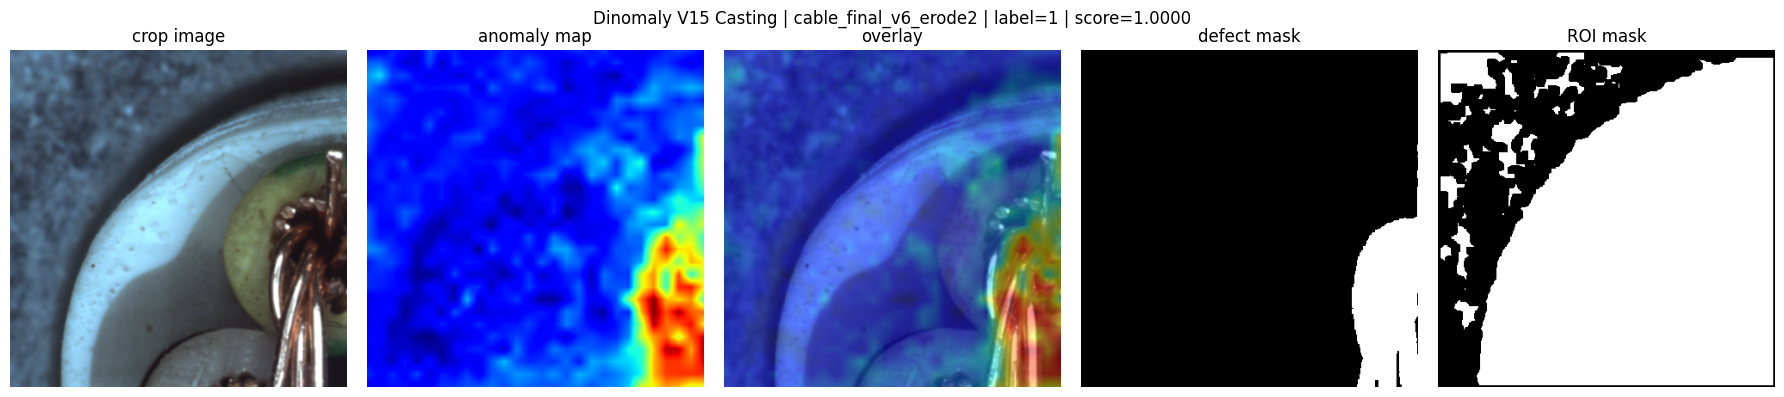

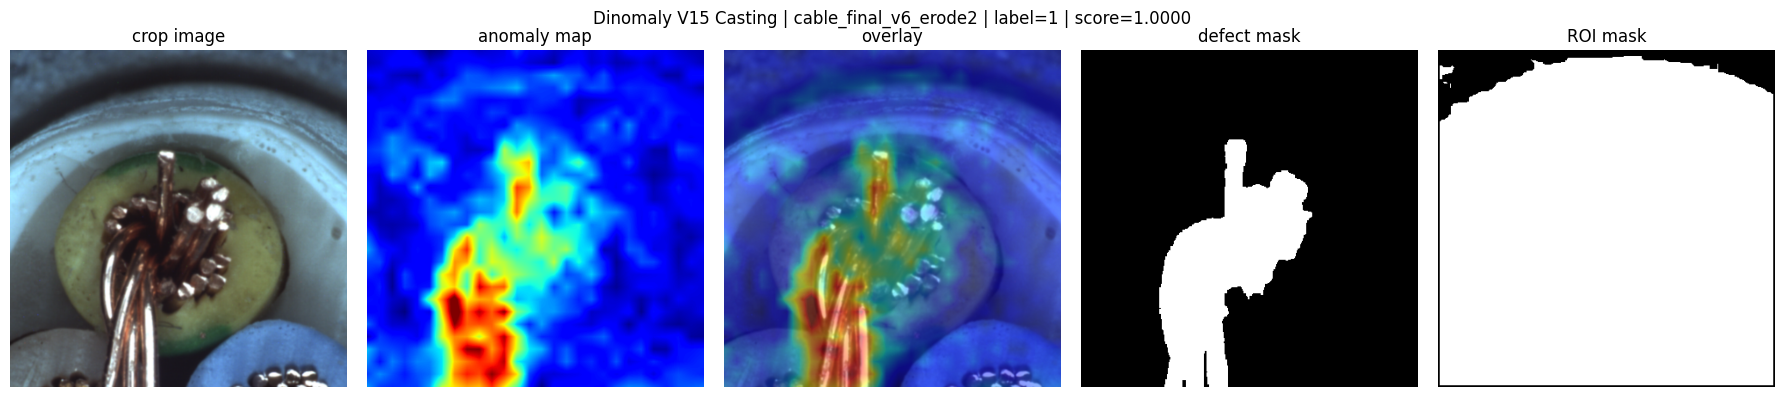

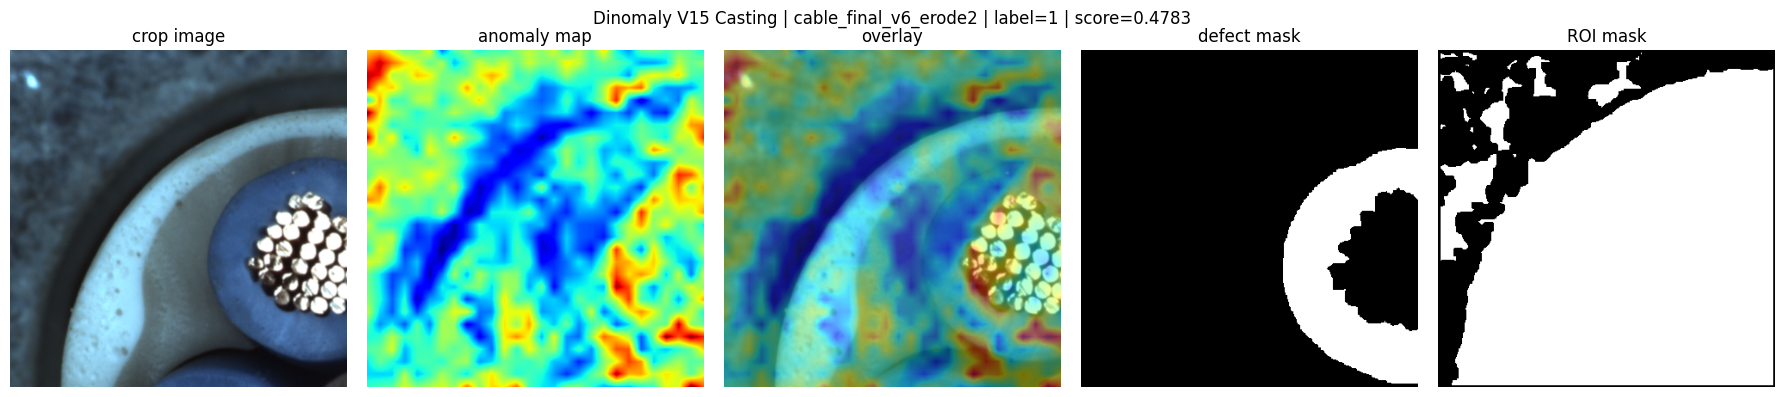

In [28]:
########################
#  Visual helpers      #
########################

def safe_open_image(path_value):
    path = project_path(path_value)

    if path is None or not path.exists():
        return None

    return Image.open(path).convert("RGB")


def show_prediction_row(row, title_prefix="Dinomaly V15"):
    img = safe_open_image(row.get("crop_image_path", ""))

    if img is None:
        img = safe_open_image(row.get("image_path", ""))

    if img is None:
        print("Image unavailable")
        return

    score_map = get_score_map(row)

    if score_map is None:
        print("Anomaly map unavailable")
        return

    mask = get_defect_mask(row, score_map.shape)
    roi = get_roi_mask(row, score_map.shape)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(img)
    axes[0].set_title("crop image")
    axes[0].axis("off")

    axes[1].imshow(score_map, cmap="jet")
    axes[1].set_title("anomaly map")
    axes[1].axis("off")

    img_resized = img.resize((score_map.shape[1], score_map.shape[0]))
    axes[2].imshow(img_resized)
    axes[2].imshow(score_map, cmap="jet", alpha=0.45)
    axes[2].set_title("overlay")
    axes[2].axis("off")

    axes[3].imshow(mask if mask is not None else np.zeros(score_map.shape), cmap="gray")
    axes[3].set_title("defect mask")
    axes[3].axis("off")

    axes[4].imshow(roi, cmap="gray")
    axes[4].set_title("ROI mask")
    axes[4].axis("off")

    title = (
        f"{title_prefix} | {row.get('variant_id')} | "
        f"label={row.get('image_true_label')} | score={row.get('score'):.4f}"
    )
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


if dinomaly_crop_predictions_df.empty or "anomaly_map" not in dinomaly_crop_predictions_df.columns:
    print("No anomaly maps available")
else:
    visual_df = dinomaly_crop_predictions_df[dinomaly_crop_predictions_df["anomaly_map"].notna()].copy()

    for variant_id in visual_df["variant_id"].unique():
        print()
        print("Visual samples for:", variant_id)
        part = visual_df[visual_df["variant_id"] == variant_id].copy()

        normal_top = part[part["image_true_label"] == 0].sort_values("score", ascending=False).head(1)
        anomaly_top = part[part["image_true_label"] == 1].sort_values("score", ascending=False).head(2)
        anomaly_low = part[part["image_true_label"] == 1].sort_values("score", ascending=True).head(1)
        samples = pd.concat([normal_top, anomaly_top, anomaly_low], ignore_index=True)

        for _, row in samples.iterrows():
            show_prediction_row(row, title_prefix="Dinomaly V15 Casting")


## 13. Sauvegarde

In [29]:
##################
#  Save outputs  #
##################

raw_metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_raw_metrics.csv"
run_status_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_run_status.csv"
metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_metrics.csv"
image_predictions_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_image_predictions.csv"
crop_predictions_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_crop_predictions.csv"
category_metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_category_metrics.csv"
defect_metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_defect_type_metrics.csv"
pixel_metrics_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_pixel_metrics_by_category.csv"
aupimo_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_aupimo_per_image_by_category.csv"
comparison_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_comparison_all.csv"
best_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_best_by_category.csv"

raw_dinomaly_metrics_df.to_csv(raw_metrics_path, index=False)
run_status_df.to_csv(run_status_path, index=False)

if not dinomaly_image_predictions_df.empty:
    y_all = dinomaly_image_predictions_df["true_label"].astype(int)
    s_all = dinomaly_image_predictions_df["score"].astype(float)
    p_all = dinomaly_image_predictions_df["pred_label"].astype(int)

    metrics_df = pd.DataFrame([{
        "model": MODEL_NAME,
        "images": len(dinomaly_image_predictions_df),
        "normal_images": int((y_all == 0).sum()),
        "anomaly_images": int((y_all == 1).sum()),
        "accuracy": accuracy_score(y_all, p_all),
        "precision": precision_score(y_all, p_all, zero_division=0),
        "recall": recall_score(y_all, p_all, zero_division=0),
        "f1_score": f1_score(y_all, p_all, zero_division=0),
        "roc_auc": roc_auc_score(y_all, s_all) if y_all.nunique() > 1 else np.nan,
        "pr_auc": average_precision_score(y_all, s_all) if y_all.nunique() > 1 else np.nan,
    }])
else:
    metrics_df = pd.DataFrame()

metrics_df.to_csv(metrics_path, index=False)
dinomaly_image_predictions_df.to_csv(image_predictions_path, index=False)

dinomaly_crop_predictions_df.drop(
    columns=["anomaly_map", "gt_mask_array"],
    errors="ignore",
).to_csv(crop_predictions_path, index=False)

category_metrics_df.to_csv(category_metrics_path, index=False)
defect_metrics_df.to_csv(defect_metrics_path, index=False)
category_pixel_metrics_df.to_csv(pixel_metrics_path, index=False)
category_aupimo_per_image_df.to_csv(aupimo_path, index=False)

if "comparison_df" in globals():
    comparison_df.to_csv(comparison_path, index=False)

if "best_final_df" in globals():
    best_final_df.to_csv(best_path, index=False)

saved_paths = [
    raw_metrics_path,
    run_status_path,
    metrics_path,
    image_predictions_path,
    crop_predictions_path,
    category_metrics_path,
    defect_metrics_path,
    pixel_metrics_path,
    aupimo_path,
    comparison_path,
    best_path,
]


# Best epoch exports
best_epoch_evaluation_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_epoch_checkpoint_evaluation.csv"
best_epoch_selection_path = RUN_RESULTS_DIR / f"{MODEL_SLUG}_best_epoch_selection.csv"

if "best_epoch_evaluation_df" in globals():
    best_epoch_evaluation_df.to_csv(best_epoch_evaluation_path, index=False)
else:
    pd.DataFrame().to_csv(best_epoch_evaluation_path, index=False)

if "best_epoch_selection_df" in globals():
    best_epoch_selection_df.to_csv(best_epoch_selection_path, index=False)
else:
    pd.DataFrame().to_csv(best_epoch_selection_path, index=False)

saved_paths.extend([
    best_epoch_evaluation_path,
    best_epoch_selection_path,
])

print("Saved outputs:")
for path in saved_paths:
    print(path)


Saved outputs:
/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints/dinomaly_final_3cat_strategy_v8_best_epoch_15epochs_checkpoints_raw_metrics.csv
/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints/dinomaly_final_3cat_strategy_v8_best_epoch_15epochs_checkpoints_run_status.csv
/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints/dinomaly_final_3cat_strategy_v8_best_epoch_15epochs_checkpoints_metrics.csv
/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessing_final_dinomaly_3cat_strategy_v8_best_epoch_15epochs_checkpoints/dinomaly_final_3cat_strategy_v8_best_epoch_15epochs_checkpoints_image_predictions.csv
/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/notebooks/results/preprocessin

## 14. Points à analyser

À regarder en priorité :

```text
1. Est ce que AUPIMO Casting remonte au dessus de PatchCore V7 ?
2. Est ce que defect centered améliore la localisation ?
3. Est ce que component ROI stabilise les heatmaps ?
4. Est ce que pixel AUROC reste correct ?
5. Est ce que image AUROC reste au dessus de V14 ?
```

Lecture :

```text
AUPIMO monte mais image AUROC baisse : meilleure localisation mais moins bon scoring image
image AUROC monte mais AUPIMO reste faible : signal global mais localisation encore mauvaise
pixel AUROC haut et AUPIMO faible : carte correcte en ranking global mais trop bruitée à faible faux positif
```
